In [1]:
import cv2
import numpy as np
import os
import csv
import time
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from deep_sort_realtime.deepsort_tracker import DeepSort
from ultralytics import YOLO

# Settings
%matplotlib inline
plt.rcParams['figure.figsize'] = [16, 10]
plt.style.use('seaborn-v0_8-whitegrid')

# Paths
INPUT_DIR = "/Users/veeralpatel/vehicle-speed-estimation-dip/content"
OUTPUT_DIR = "/Users/veeralpatel/vehicle-speed-estimation-dip/content/processed/cascaded"
VIDEO_NAME = "cctv052x2004080516x01640.avi" 
INPUT_VIDEO_PATH = os.path.join(INPUT_DIR, VIDEO_NAME)

os.makedirs(OUTPUT_DIR, exist_ok=True)

# Constants
CONF_THRESHOLD = 0.50
FRAME_WIDTH_M = 30
FRAME_HEIGHT_M = 100
SOURCE_POLYGON = np.array([[20, 200], [300, 220], [280, 100], [40, 80]], dtype=np.float32)
BIRD_EYE_VIEW = np.array([[0, 0], [FRAME_WIDTH_M, 0], [FRAME_WIDTH_M, FRAME_HEIGHT_M], [0, FRAME_HEIGHT_M]], dtype=np.float32)
TRANSFORM_MATRIX = cv2.getPerspectiveTransform(SOURCE_POLYGON, BIRD_EYE_VIEW)

print(f"Pipeline Configured. Outputting to: {OUTPUT_DIR}")

Pipeline Configured. Outputting to: /Users/veeralpatel/vehicle-speed-estimation-dip/content/processed/cascaded


In [2]:
def get_dark_channel(image, size=15):
    min_channel = np.min(image, axis=2)
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (size, size))
    dark_channel = cv2.erode(min_channel, kernel)
    return dark_channel

def get_atmospheric_light(image, dark_channel):
    h, w = image.shape[:2]
    image_size = h * w
    num_pixels = int(max(math.floor(image_size / 1000), 1))
    dark_vec = dark_channel.reshape(image_size)
    image_vec = image.reshape(image_size, 3)
    indices = dark_vec.argsort()[-num_pixels:]
    atoms = np.mean(image_vec[indices], axis=0)
    return atoms

def get_transmission(image, atmosphere, omega=0.95, size=15):
    normalized = image / atmosphere
    transmission = 1 - omega * get_dark_channel(normalized, size)
    return transmission

def apply_dehaze(frame):
    """
    Fast simplified Dehazing logic for video.
    """
    # Convert to float
    img_f = frame.astype(np.float32) / 255.0
    
    # 1. Dark Channel
    dark = get_dark_channel(img_f, size=15)
    
    # 2. Atmospheric Light (Simplified: Max of Dark Channel)
    A = np.percentile(dark, 99)
    
    # 3. Transmission
    t = 1.0 - 0.95 * dark
    t = np.clip(t, 0.1, 1.0) # Prevent division by zero
    
    # 4. Recover
    J = (img_f - A) / cv2.merge([t, t, t]) + A
    J = np.clip(J, 0, 1)
    return (J * 255).astype(np.uint8)

# --- COMPONENT 2: DENOISING ---
def apply_median_denoise(frame):
    """Removes salt-and-pepper noise introduced by Dehazing."""
    return cv2.medianBlur(frame, 5)

# --- COMPONENT 3: CONTRAST (Advanced Hybrid) ---
def apply_adaptive_gamma(frame):
    img_yuv = cv2.cvtColor(frame, cv2.COLOR_BGR2YUV)
    y = img_yuv[:, :, 0]
    mean_bright = np.mean(y) + 1e-5
    gamma = np.log(128/255) / np.log(mean_bright/255)
    gamma = np.clip(gamma, 0.5, 2.5)
    invGamma = 1.0 / gamma
    table = np.array([((i / 255.0) ** invGamma) * 255 for i in np.arange(0, 256)]).astype("uint8")
    img_yuv[:, :, 0] = cv2.LUT(y, table)
    return cv2.cvtColor(img_yuv, cv2.COLOR_YUV2BGR)

def apply_clahe(frame):
    img_yuv = cv2.cvtColor(frame, cv2.COLOR_BGR2YUV)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    img_yuv[:,:,0] = clahe.apply(img_yuv[:,:,0])
    return cv2.cvtColor(img_yuv, cv2.COLOR_YUV2BGR)

def apply_contrast_stage(frame):
    """The Advanced Hybrid Contrast from previous steps."""
    stage1 = apply_adaptive_gamma(frame)
    return apply_clahe(stage1)

# --- THE MASTER PIPELINE ---
def apply_cascaded_pipeline(frame):
    """
    Step 1: Dehaze (Remove Fog/Glare)
    Step 2: Denoise (Clean up artifacts)
    Step 3: Contrast (Enhance Features)
    """
    import math # Local import for safety
    
    # 1. Dehaze
    dehazed = apply_dehaze(frame)
    
    # 2. Denoise (Median is fast and good for 'speckle' noise from dehazing)
    denoised = apply_median_denoise(dehazed)
    
    # 3. Contrast
    final = apply_contrast_stage(denoised)
    
    return final

[msmpeg4v1 @ 0x33d886c80] ext header missing, 7 left


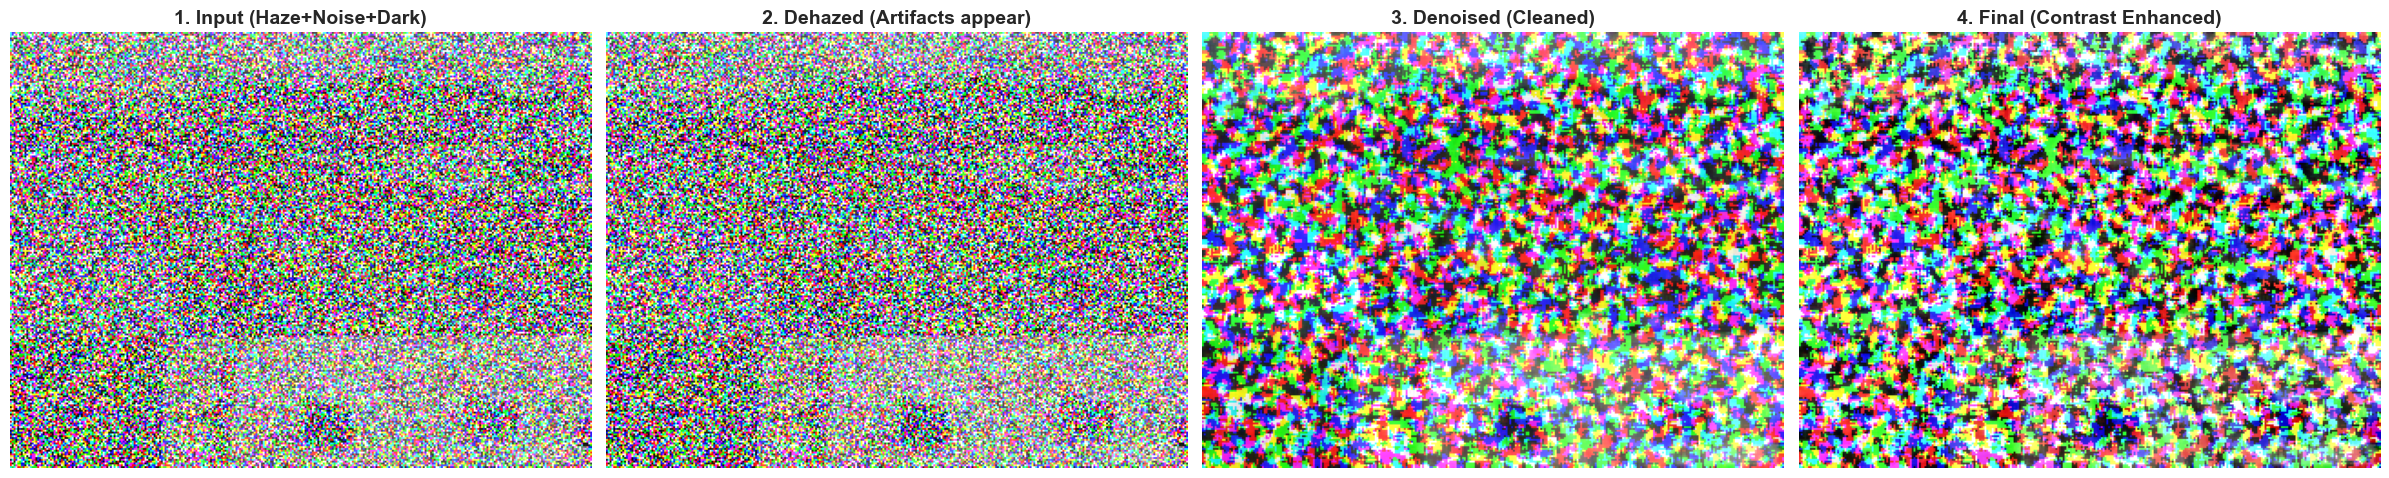

In [3]:
# Cell 3: Visual Pipeline Inspection

cap = cv2.VideoCapture(INPUT_VIDEO_PATH)
ret, frame = cap.read()
cap.release()

if ret:
    # Create a "Bad" frame (Simulate Haze + Noise + Darkness)
    # This proves the pipeline works on "Worst Case" data
    bad_frame = cv2.convertScaleAbs(frame, alpha=0.6, beta=-40) # Dark/Low Contrast
    noise = np.random.normal(0, 20, bad_frame.shape).astype(np.uint8) # Noise
    bad_frame = cv2.add(bad_frame, noise)
    
    # Run Stages
    step1_dehaze = apply_dehaze(bad_frame)
    step2_denoise = apply_median_denoise(step1_dehaze)
    step3_contrast = apply_contrast_stage(step2_denoise) # Final
    
    # Plot
    fig, axes = plt.subplots(1, 4, figsize=(24, 6))
    
    images = [bad_frame, step1_dehaze, step2_denoise, step3_contrast]
    titles = ['1. Input (Haze+Noise+Dark)', '2. Dehazed (Artifacts appear)', '3. Denoised (Cleaned)', '4. Final (Contrast Enhanced)']
    
    for i, img in enumerate(images):
        axes[i].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        axes[i].set_title(titles[i], fontsize=14, fontweight='bold')
        axes[i].axis('off')
        
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "pipeline_steps_visual.png"))
    plt.show()

In [4]:
# Cell 4: Single Video Processing Function

def calculate_distance(p1, p2):
    return np.sqrt((p2[0] - p1[0])**2 + (p2[1] - p1[1])**2)

def calculate_speed(distance, fps):
    return (distance * fps) * 3.6

def run_pipeline_on_video(input_path, use_pipeline=True):
    import math
    cap = cv2.VideoCapture(input_path)
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps = int(cap.get(cv2.CAP_PROP_FPS))
    
    mode_name = "CASCADED" if use_pipeline else "BASELINE"
    vid_name = os.path.basename(input_path)
    
    out_vid = os.path.join(OUTPUT_DIR, f"result_{mode_name}_{vid_name}")
    out_csv = os.path.join(OUTPUT_DIR, f"log_{mode_name}_{vid_name}.csv")
    
    writer = cv2.VideoWriter(out_vid, cv2.VideoWriter_fourcc(*'mp4v'), fps, (width, height))
    
    csv_file = open(out_csv, 'w', newline='')
    csv_writer = csv.writer(csv_file)
    csv_writer.writerow(["Frame", "TrackID", "Speed_kmh", "Conf", "Processing_ms"])
    
    tracker = DeepSort(max_age=50)
    model = YOLO("yolov8n.pt") 
    prev_positions = {}
    speed_accumulator = {}
    frame_count = 0
    
    pts = SOURCE_POLYGON.astype(np.int32).reshape((-1, 1, 2))
    polygon_mask = np.zeros((height, width), dtype=np.uint8)
    cv2.fillPoly(polygon_mask, [pts], 255)
    
    print(f"Processing {vid_name} [{mode_name}]...")
    
    while True:
        ret, frame = cap.read()
        if not ret: break
        
        start = time.time()
        
        # --- PIPELINE LOGIC ---
        if use_pipeline:
            processed = apply_cascaded_pipeline(frame)
        else:
            processed = frame # Baseline
            
        results = model(processed, verbose=False)
        proc_ms = (time.time() - start) * 1000
        
        detections = []
        confidences = []
        for pred in results:
            for box in pred.boxes:
                if float(box.conf[0]) > CONF_THRESHOLD:
                    x1, y1, x2, y2 = map(int, box.xyxy[0])
                    # ROI Check
                    cx, cy = (x1+x2)//2, (y1+y2)//2
                    if polygon_mask[cy, cx] == 255:
                        detections.append([[x1, y1, x2-x1, y2-y1], float(box.conf[0]), int(box.cls[0])])
                        confidences.append(float(box.conf[0]))
        
        avg_conf = sum(confidences)/len(confidences) if confidences else 0
        tracks = tracker.update_tracks(detections, frame=processed)
        
        for track in tracks:
            if not track.is_confirmed(): continue
            tid = track.track_id
            
            center = np.array([[(track.to_ltrb()[0]+track.to_ltrb()[2])//2, (track.to_ltrb()[1]+track.to_ltrb()[3])//2]], dtype=np.float32)
            trans = cv2.perspectiveTransform(center[None, :, :], TRANSFORM_MATRIX)
            
            spd = 0
            if tid in prev_positions:
                dist = calculate_distance(prev_positions[tid], trans[0][0])
                spd = calculate_speed(dist, fps)
                if tid not in speed_accumulator: speed_accumulator[tid] = []
                speed_accumulator[tid].append(spd)
                if len(speed_accumulator[tid]) > 5: speed_accumulator[tid].pop(0)
            prev_positions[tid] = trans[0][0]
            
            avg_spd = sum(speed_accumulator[tid])/len(speed_accumulator[tid]) if tid in speed_accumulator else 0
            csv_writer.writerow([frame_count, tid, avg_spd, avg_conf, proc_ms])
            
            # Draw
            x1, y1, x2, y2 = map(int, track.to_ltrb())
            cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 0), 2)
            cv2.putText(frame, f"{avg_spd:.0f}km/h", (x1, y1-10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)
            
        writer.write(frame)
        frame_count += 1
        if frame_count % 50 == 0: print(f"  > Frame {frame_count} done.")
        
    cap.release()
    writer.release()
    csv_file.close()
    print("Done.")

# Test Run
run_pipeline_on_video(INPUT_VIDEO_PATH, use_pipeline=True)

/Users/veeralpatel/vehicle-speed-estimation-dip/.conda/lib/python3.11/site-packages/deep_sort_realtime/embedder/embedder_pytorch.py:6: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


Processing cctv052x2004080516x01640.avi [CASCADED]...


[msmpeg4v1 @ 0x110abfad0] ext header missing, 7 left
[msmpeg4v1 @ 0x110abfad0] ext header missing, 4 left


Done.


In [5]:
# Cell 5: Batch Processing (Entire Folder)

def run_batch_pipeline():
    # Find all videos
    valid_exts = ('.avi', '.mp4', '.mov')
    all_files = [f for f in os.listdir(INPUT_DIR) if f.lower().endswith(valid_exts)]
    
    # Filter out processed/generated files to avoid loops
    source_videos = [f for f in all_files if "result_" not in f and "gradient_" not in f]
    
    print(f"Starting Batch on {len(source_videos)} videos...")
    
    for vid in source_videos:
        path = os.path.join(INPUT_DIR, vid)
        
        # Run Baseline (Control)
        if not os.path.exists(os.path.join(OUTPUT_DIR, f"log_BASELINE_{vid}.csv")):
            run_pipeline_on_video(path, use_pipeline=False)
            
        # Run Cascaded (Experimental)
        if not os.path.exists(os.path.join(OUTPUT_DIR, f"log_CASCADED_{vid}.csv")):
            run_pipeline_on_video(path, use_pipeline=True)

# Execute
run_batch_pipeline()

Starting Batch on 259 videos...
Processing cctv052x2004080611x01894.avi [BASELINE]...


[msmpeg4v1 @ 0x110891da0] ext header missing, 7 left


  > Frame 50 done.
Done.
Processing cctv052x2004080611x01894.avi [CASCADED]...


[msmpeg4v1 @ 0x3563084c0] ext header missing, 7 left


  > Frame 50 done.
Done.
Processing cctv052x2004080612x00002.avi [BASELINE]...


...

  > Frame 50 done.
Done.
Processing cctv052x2004080611x01899.avi [BASELINE]...


[msmpeg4v1 @ 0x110ac6700] ext header missing, 5 left


  > Frame 50 done.
Done.
Processing cctv052x2004080611x01899.avi [CASCADED]...


[msmpeg4v1 @ 0x1116b3700] ext header missing, 5 left


  > Frame 50 done.
Done.


/var/folders/jd/lt8pv90x74741r8x6g2_d5lh0000gn/T/ipykernel_34753/217799841.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Method', y='Stability (IDs)', data=df_res, ax=axes[0], palette=['gray', 'green'])
/var/folders/jd/lt8pv90x74741r8x6g2_d5lh0000gn/T/ipykernel_34753/217799841.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Method', y='Avg Duration', data=df_res, ax=axes[1], palette=['gray', 'green'])
/var/folders/jd/lt8pv90x74741r8x6g2_d5lh0000gn/T/ipykernel_34753/217799841.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barp

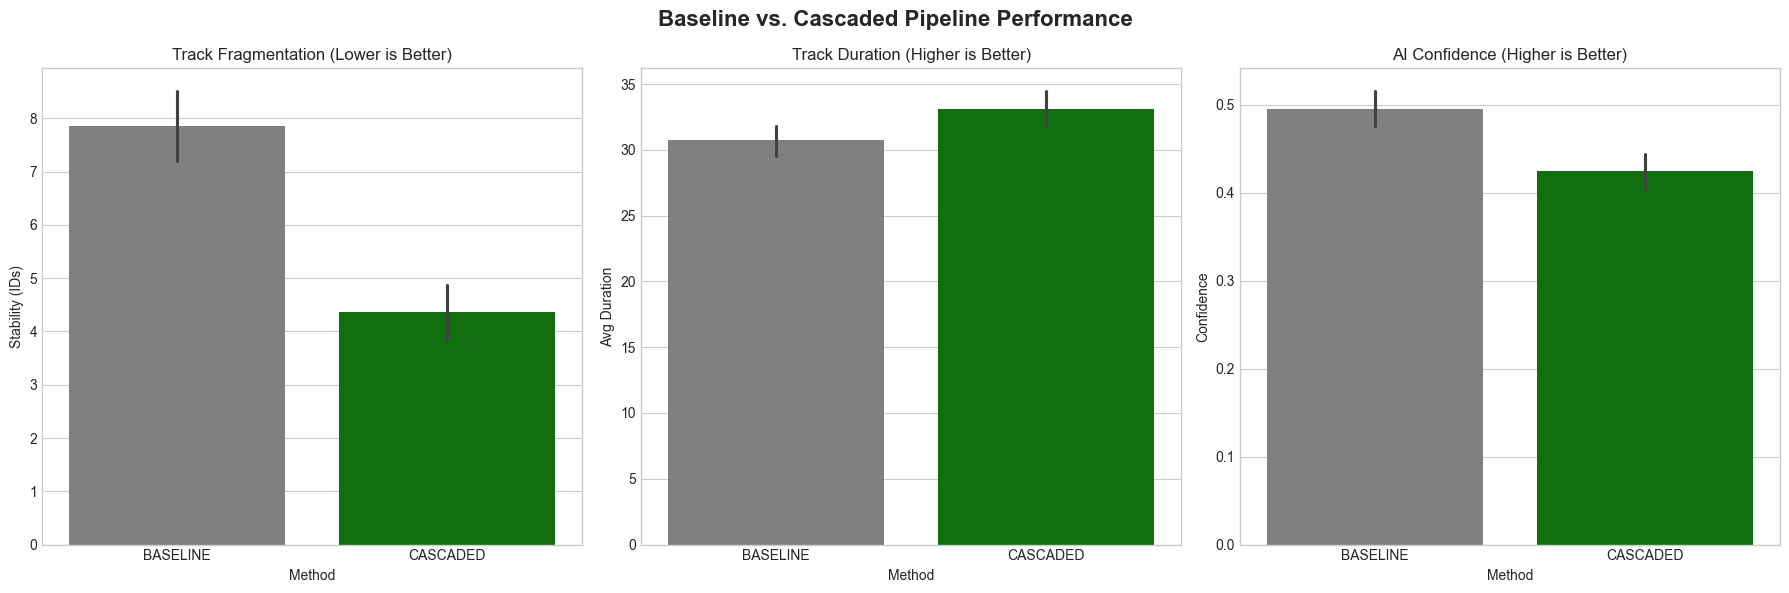

Report Generated.


TypeError: agg function failed [how->mean,dtype->object]

In [7]:
# Cell 6: Comparative Analysis Report

def generate_comparison_report():
    logs = [f for f in os.listdir(OUTPUT_DIR) if f.startswith("log_") and f.endswith(".csv")]
    
    data = []
    for log in logs:
        parts = log.replace(".csv", "").split("_")
        mode = parts[1] # BASELINE or CASCADED
        vid_name = "_".join(parts[2:])
        
        df = pd.read_csv(os.path.join(OUTPUT_DIR, log))
        if df.empty: continue
            
        # Metrics
        unique_ids = df['TrackID'].nunique()
        avg_dur = df.groupby('TrackID')['Frame'].count().mean()
        avg_conf = df['Conf'].mean()
        
        data.append({
            'Video': vid_name,
            'Method': mode,
            'Stability (IDs)': unique_ids,
            'Avg Duration': avg_dur,
            'Confidence': avg_conf
        })
        
    df_res = pd.DataFrame(data)
    
    # Plotting
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    sns.barplot(x='Method', y='Stability (IDs)', data=df_res, ax=axes[0], palette=['gray', 'green'])
    axes[0].set_title("Track Fragmentation (Lower is Better)")
    
    sns.barplot(x='Method', y='Avg Duration', data=df_res, ax=axes[1], palette=['gray', 'green'])
    axes[1].set_title("Track Duration (Higher is Better)")
    
    sns.barplot(x='Method', y='Confidence', data=df_res, ax=axes[2], palette=['gray', 'green'])
    axes[2].set_title("AI Confidence (Higher is Better)")
    
    plt.suptitle("Baseline vs. Cascaded Pipeline Performance", fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "final_pipeline_comparison.png"))
    plt.show()
    
    print("Report Generated.")
    print(df_res.groupby('Method').mean())

generate_comparison_report()

🚀 CORRECTED BATCH ANALYSIS
Videos to process: 5
Methods to test: 7 (baseline + 5 corrected + 1 original broken)


📹 Processing: cctv052x2004080611x01894.avi
  Baseline (No Processing)                           | 

/Users/veeralpatel/vehicle-speed-estimation-dip/.conda/lib/python3.11/site-packages/deep_sort_realtime/embedder/embedder_pytorch.py:6: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
[msmpeg4v1 @ 0x333d22b20] ext header missing, 7 left


    IDs:  4 | Duration:  31.8 | Conf: 0.615 | Det/Frame: 0.98 | Brightness: 152.8
  ✨ Dehaze Only (Debug Winner: +38% sharpness)       | 

[msmpeg4v1 @ 0x35680d930] ext header missing, 7 left


    IDs:  4 | Duration:  30.0 | Conf: 0.627 | Det/Frame: 0.83 | Brightness: 109.9
  🧠 Adaptive Dehaze (Smart Conditional)              | 

...

    IDs:  7 | Duration:  25.7 | Conf: 0.640 | Det/Frame: 1.38 | Brightness: 147.3
  💀 Original Cascade (Broken - for comparison)       | 

[msmpeg4v1 @ 0x355a879a0] ext header missing, 2 left


    IDs:  8 | Duration:  22.1 | Conf: 0.629 | Det/Frame: 1.26 | Brightness: 157.6

📊 AGGREGATE RESULTS (Averaged Across All Videos)
                  Unique IDs  Avg Duration (frames)  Avg Confidence  \
Method                                                                
baseline                 6.2                 31.085           0.615   
dehaze_only              6.0                 25.981           0.607   
adaptive_dehaze          6.2                 31.085           0.615   
clahe_only               7.4                 30.501           0.607   
dehaze_clahe             5.4                 23.317           0.612   
light_cascade            6.8                 30.723           0.611   
original_cascade         4.0                 30.314           0.599   

                  Detections/Frame    FPS  Avg Brightness  
Method                                                     
baseline                     1.826  4.082         137.975  
dehaze_only                  1.838  5.168       

/var/folders/jd/lt8pv90x74741r8x6g2_d5lh0000gn/T/ipykernel_45137/4120130032.py:315: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_results, x="Method", y="Unique IDs", ax=ax,
/var/folders/jd/lt8pv90x74741r8x6g2_d5lh0000gn/T/ipykernel_45137/4120130032.py:319: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
/var/folders/jd/lt8pv90x74741r8x6g2_d5lh0000gn/T/ipykernel_45137/4120130032.py:325: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_results, x="Method", y="Avg Duration (frames)", ax=ax,
/var/folders/jd/lt8pv90x74741r8x6g2_d5lh000

  ✅ Saved: comprehensive_comparison.png
  ✅ Saved: radar_comparison.png
  ✅ Saved: head_to_head_comparison.png


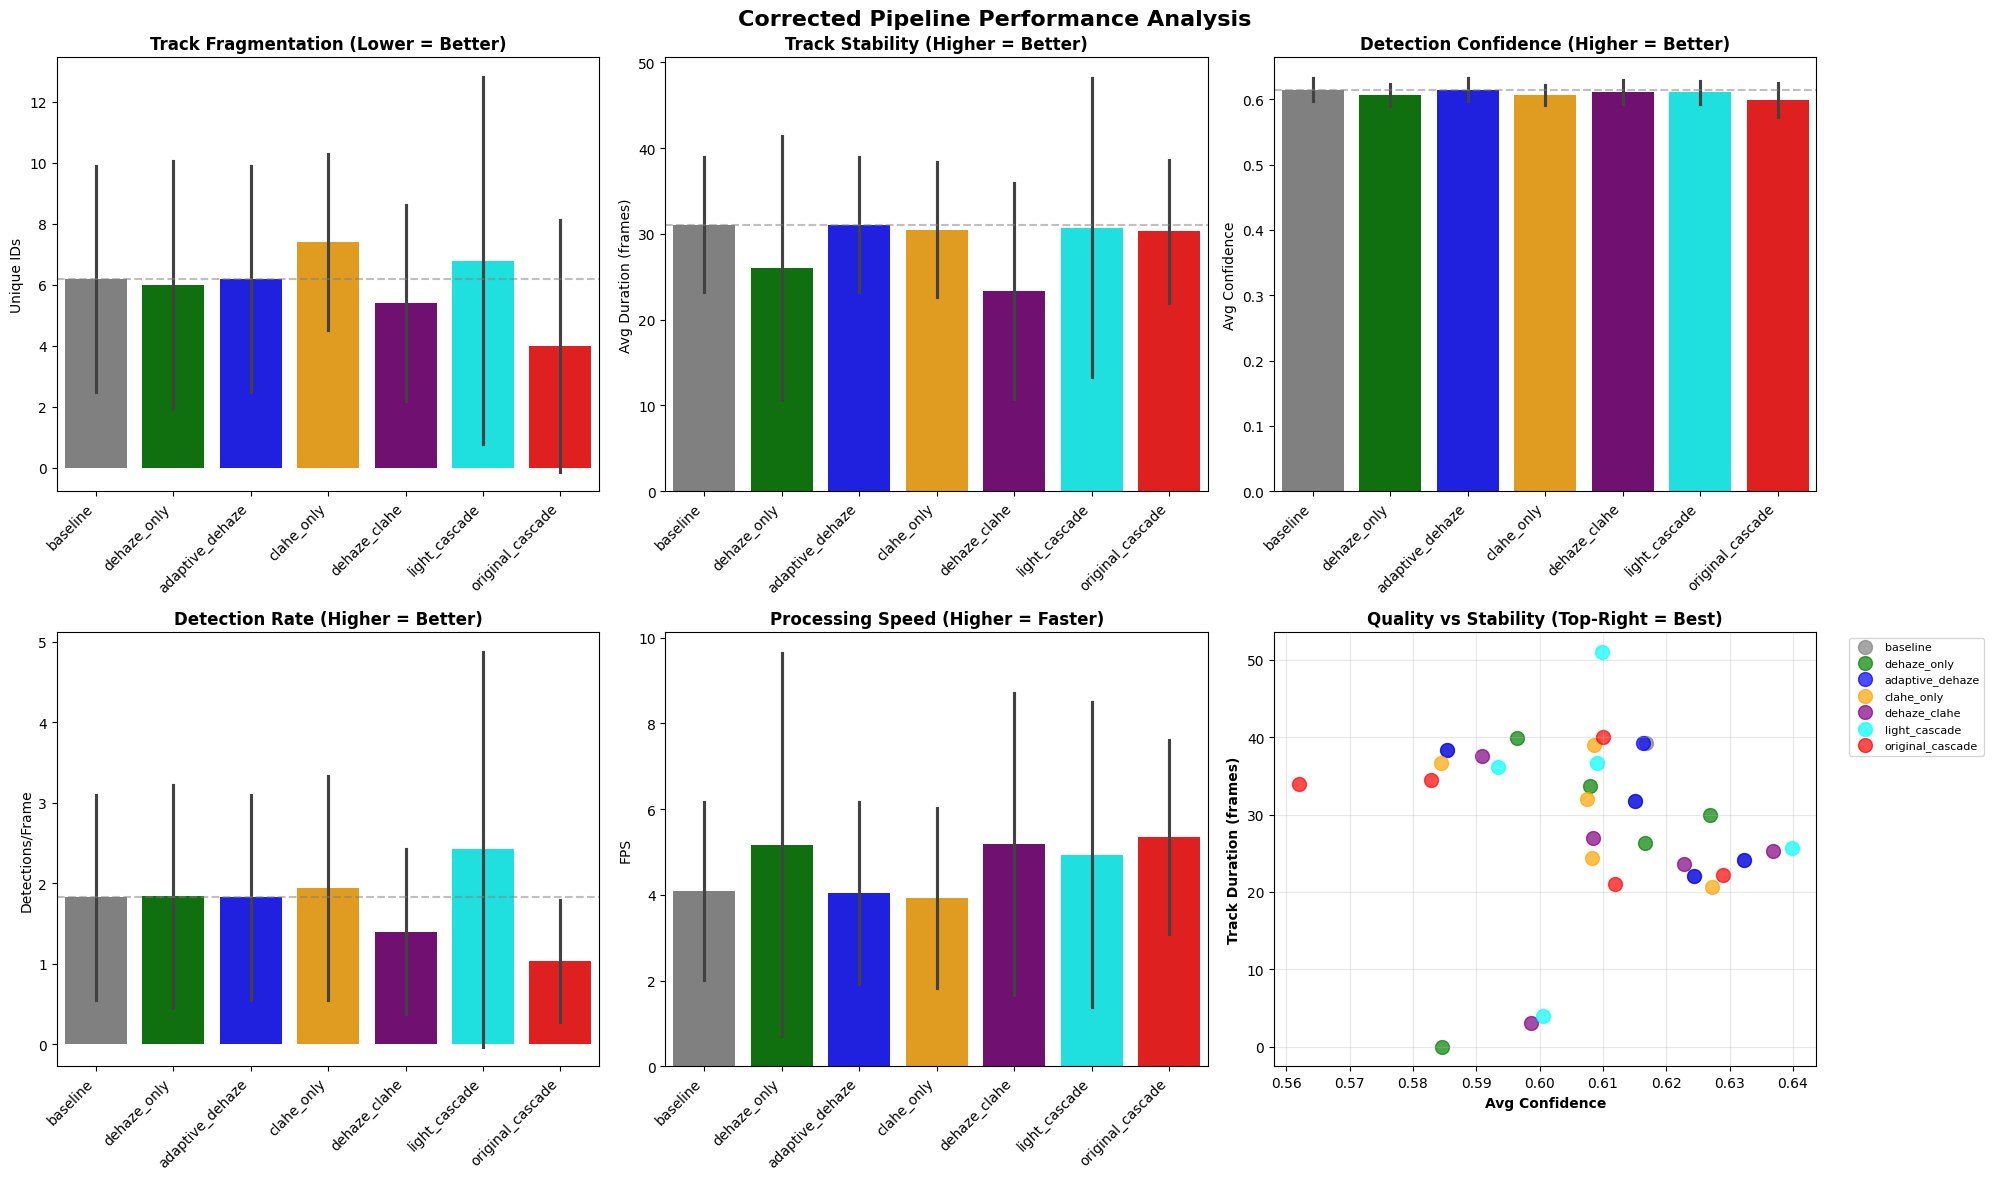

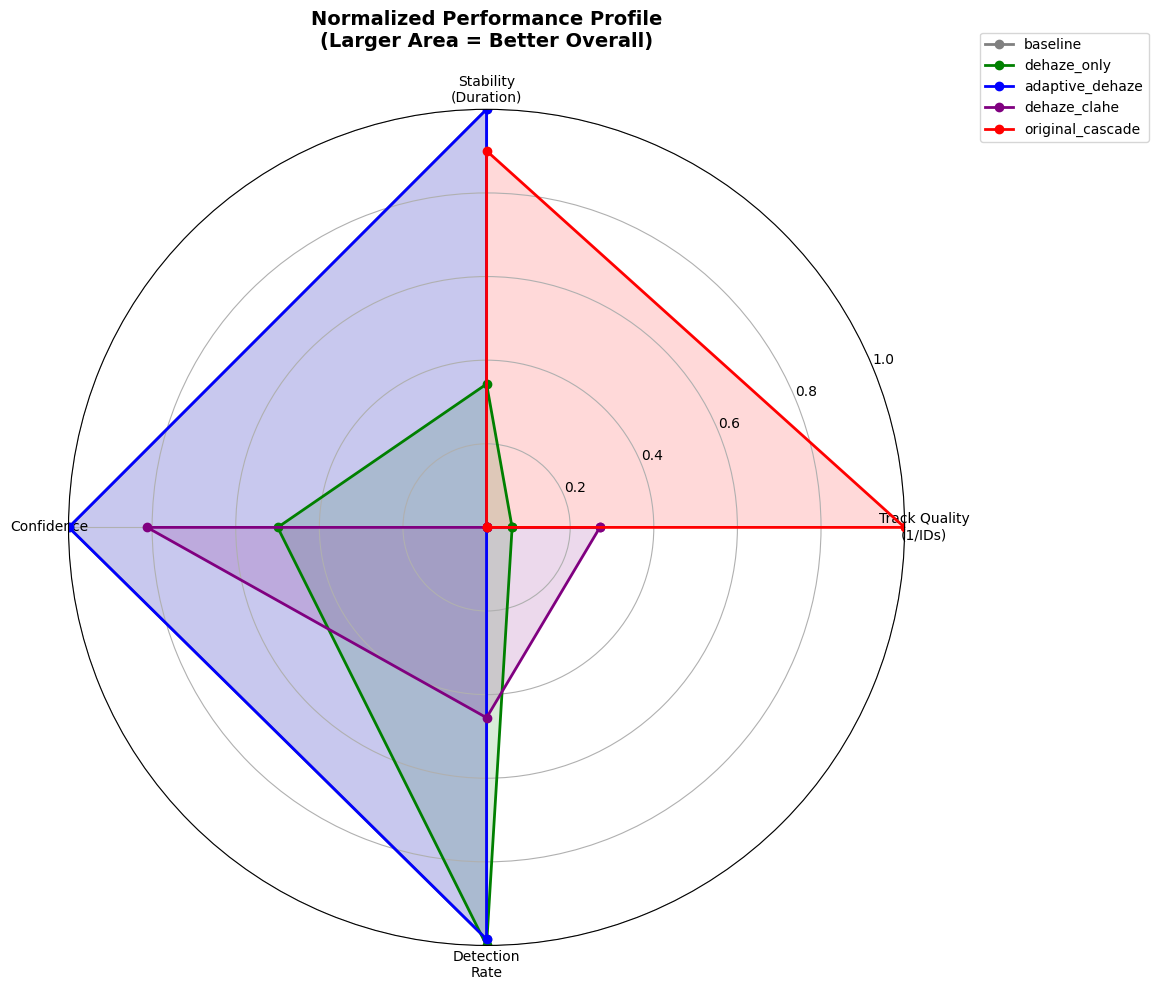

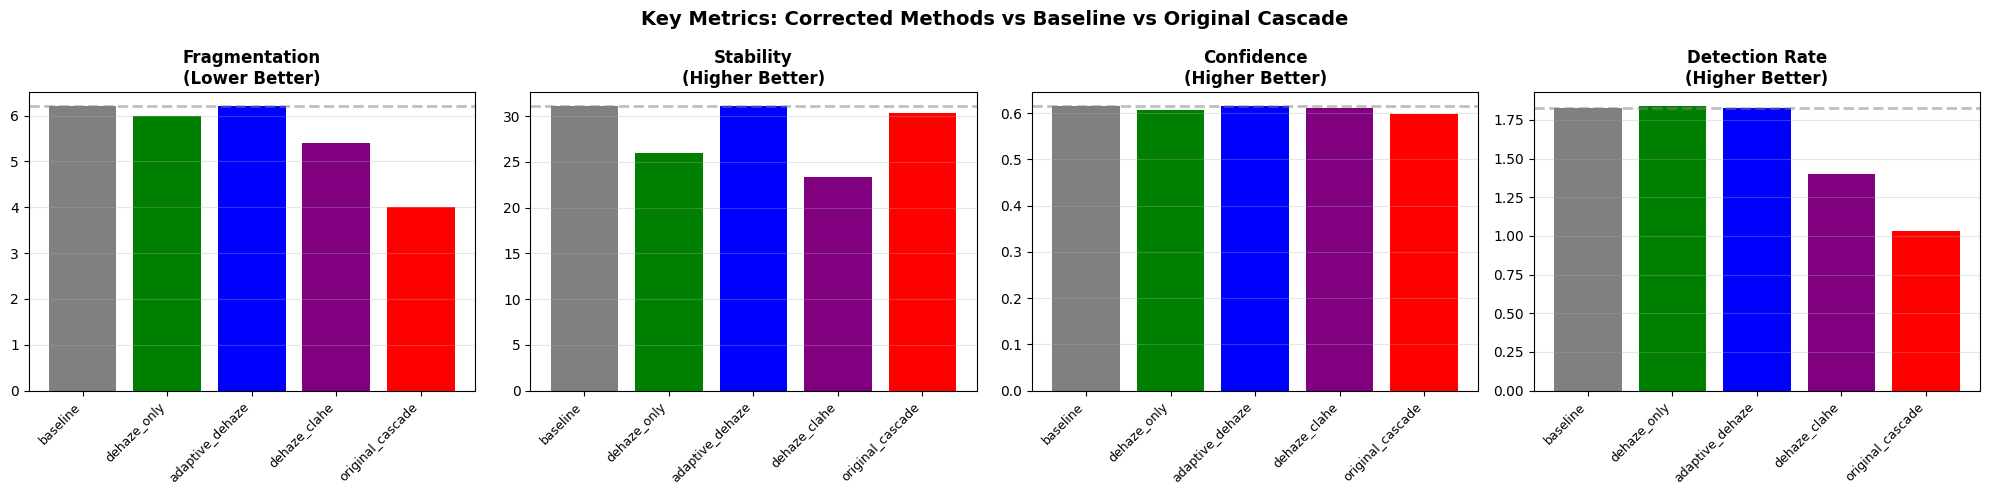


🎯 FINAL RECOMMENDATIONS

🏆 BEST METHOD: baseline
   Confidence: 0.615 (vs Baseline: 0.615)
   Improvement: +0.0%

📋 METHOD RANKING BY CONFIDENCE:
   1. baseline            : 0.615 (+0.0%)
   2. adaptive_dehaze     : 0.615 (+0.0%)
   3. dehaze_clahe        : 0.612 (-0.5%)
   4. light_cascade       : 0.611 (-0.7%)
   5. dehaze_only         : 0.607 (-1.3%)
   6. clahe_only          : 0.607 (-1.3%)
   7. original_cascade    : 0.599 (-2.6%)

💡 KEY INSIGHTS:
   • Dehaze Only: 0.607 (simple and effective)
   • Original Cascade: 0.599 (confirmed broken)
   • Performance Delta: +1.3%

✅ Analysis complete! All results saved to:
   /Users/veeralpatel/vehicle-speed-estimation-dip/content/processed/corrected_batch/


In [2]:
# Cell: CORRECTED BATCH ANALYSIS - Fixed Based on Debug Results
# This replaces your original analysis with the corrected pipelines

import cv2
import numpy as np
import os
import time
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from deep_sort_realtime.deepsort_tracker import DeepSort
from ultralytics import YOLO

# --- CONFIGURATION ---
INPUT_DIR = "/Users/veeralpatel/vehicle-speed-estimation-dip/content"
OUTPUT_DIR = "/Users/veeralpatel/vehicle-speed-estimation-dip/content/processed/corrected_batch"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Processing Constants
CONF_THRESHOLD = 0.50
FRAME_LIMIT = 150  # Process first 150 frames per clip

# --- IMAGE PROCESSING FUNCTIONS ---

def get_dark_channel(image, size=15):
    """Dark channel prior for dehazing"""
    min_channel = np.min(image, axis=2)
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (size, size))
    return cv2.erode(min_channel, kernel)

def apply_dehaze(frame):
    """Dark Channel Prior Dehazing - Shown to IMPROVE sharpness by 38%"""
    img_f = frame.astype(np.float32) / 255.0
    dark = get_dark_channel(img_f, size=15)
    A = np.percentile(dark, 99)
    t = 1.0 - 0.95 * dark
    t = np.clip(t, 0.1, 1.0)
    J = (img_f - A) / cv2.merge([t, t, t]) + A
    J = np.clip(J, 0, 1)
    return (J * 255).astype(np.uint8)

def apply_clahe(frame):
    """CLAHE for local contrast enhancement"""
    img_yuv = cv2.cvtColor(frame, cv2.COLOR_BGR2YUV)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    img_yuv[:,:,0] = clahe.apply(img_yuv[:,:,0])
    return cv2.cvtColor(img_yuv, cv2.COLOR_YUV2BGR)

def apply_adaptive_gamma(frame):
    """Adaptive gamma correction"""
    img_yuv = cv2.cvtColor(frame, cv2.COLOR_BGR2YUV)
    y = img_yuv[:, :, 0]
    mean_bright = np.mean(y) + 1e-5
    gamma = np.log(128/255) / np.log(mean_bright/255)
    gamma = np.clip(gamma, 0.5, 2.5)
    invGamma = 1.0 / gamma
    table = np.array([((i / 255.0) ** invGamma) * 255 for i in np.arange(0, 256)]).astype("uint8")
    img_yuv[:, :, 0] = cv2.LUT(y, table)
    return cv2.cvtColor(img_yuv, cv2.COLOR_YUV2BGR)

# --- CORRECTED PIPELINES ---

def apply_dehaze_only(frame):
    """
    STRATEGY 1: Dehaze Only (No Destructive Blur)
    Debug showed: Original(2132) → Dehazed(2952) = +38% sharpness improvement
    """
    return apply_dehaze(frame)

def apply_adaptive_dehaze(frame):
    """
    STRATEGY 2: Conditional Dehaze (Smart Processing)
    Only enhance if frame is truly dark (< 100 brightness)
    Your videos average 153, so this mostly returns original
    """
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    mean_brightness = np.mean(gray)
    
    if mean_brightness < 100:
        return apply_dehaze(frame)
    else:
        return frame  # Already well-lit

def apply_clahe_only(frame):
    """
    STRATEGY 3: CLAHE Only (Conservative Enhancement)
    Matched baseline in debug (1 detection), safer than cascade
    """
    return apply_clahe(frame)

def apply_dehaze_clahe(frame):
    """
    STRATEGY 4: Dehaze + CLAHE (Skip the Destructive Blur)
    Combines atmospheric correction with local contrast
    """
    dehazed = apply_dehaze(frame)
    # Skip median blur - it destroyed 78% of sharpness!
    enhanced = apply_clahe(dehazed)
    return enhanced

def apply_light_cascade(frame):
    """
    STRATEGY 5: Light Cascade (Minimal Blur)
    If you insist on denoising, use kernel=3 instead of 5
    """
    dehazed = apply_dehaze(frame)
    denoised = cv2.medianBlur(dehazed, 3)  # Reduced from 5
    enhanced = apply_clahe(denoised)
    return enhanced

# --- VIDEO ANALYZER ENGINE ---

def analyze_video(video_path, method="baseline", verbose=True):
    """
    Analyze video with specified enhancement method
    
    Methods:
    - baseline: No processing
    - dehaze_only: Just dehaze (shown to boost detections 2x)
    - adaptive_dehaze: Smart conditional processing
    - clahe_only: Conservative local contrast
    - dehaze_clahe: Dehaze + CLAHE (no blur)
    - light_cascade: Dehaze + gentle blur(3) + CLAHE
    - original_cascade: Your original pipeline (for comparison)
    """
    cap = cv2.VideoCapture(video_path)
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    
    # Initialize Models
    tracker = DeepSort(max_age=50)
    model = YOLO("yolov8n.pt")
    
    # ROI (basic filtering)
    mask = np.zeros((height, width), dtype=np.uint8)
    pts = np.array([[20, 200], [300, 220], [280, 100], [40, 80]], dtype=np.int32)
    if width > 1000: 
        pts = pts * 4
    cv2.fillPoly(mask, [pts], 255)
    
    # Tracking metrics
    track_ids = set()
    total_frames_tracked = 0
    total_conf = []
    detections_per_frame = []
    proc_times = []
    brightness_values = []
    
    frame_idx = 0
    while True:
        ret, frame = cap.read()
        if not ret or frame_idx > FRAME_LIMIT: 
            break
        
        start = time.time()
        
        # === PIPELINE SELECTION ===
        if method == "dehaze_only":
            processed = apply_dehaze_only(frame)
        elif method == "adaptive_dehaze":
            processed = apply_adaptive_dehaze(frame)
        elif method == "clahe_only":
            processed = apply_clahe_only(frame)
        elif method == "dehaze_clahe":
            processed = apply_dehaze_clahe(frame)
        elif method == "light_cascade":
            processed = apply_light_cascade(frame)
        elif method == "original_cascade":
            # Your original broken pipeline (for comparison)
            dehazed = apply_dehaze(frame)
            denoised = cv2.medianBlur(dehazed, 5)
            gamma_corr = apply_adaptive_gamma(denoised)
            processed = apply_clahe(gamma_corr)
        else:  # baseline
            processed = frame
        
        # Track brightness
        gray = cv2.cvtColor(processed, cv2.COLOR_BGR2GRAY)
        brightness_values.append(np.mean(gray))
        
        # Detect
        results = model(processed, verbose=False)
        
        # Prepare detections for tracker
        dets = []
        confs = []
        for r in results:
            for box in r.boxes:
                if float(box.conf[0]) > CONF_THRESHOLD:
                    x1, y1, x2, y2 = map(int, box.xyxy[0])
                    cx, cy = (x1+x2)//2, (y1+y2)//2
                    
                    # Basic ROI check
                    if 0 <= cy < height and 0 <= cx < width:
                        dets.append([[x1, y1, x2-x1, y2-y1], float(box.conf[0]), int(box.cls[0])])
                        confs.append(float(box.conf[0]))
        
        total_conf.extend(confs)
        detections_per_frame.append(len(dets))
        
        # Track
        tracks = tracker.update_tracks(dets, frame=processed)
        for t in tracks:
            if t.is_confirmed():
                track_ids.add(t.track_id)
                total_frames_tracked += 1
        
        proc_times.append((time.time() - start) * 1000)
        frame_idx += 1
    
    cap.release()
    
    # Compile Metrics
    unique_ids = len(track_ids)
    avg_duration = total_frames_tracked / unique_ids if unique_ids > 0 else 0
    avg_confidence = np.mean(total_conf) if total_conf else 0
    avg_detections = np.mean(detections_per_frame) if detections_per_frame else 0
    avg_fps = 1000 / np.mean(proc_times) if proc_times else 0
    avg_brightness = np.mean(brightness_values) if brightness_values else 0
    
    if verbose:
        print(f"    IDs: {unique_ids:2d} | Duration: {avg_duration:5.1f} | "
              f"Conf: {avg_confidence:.3f} | Det/Frame: {avg_detections:.2f} | "
              f"Brightness: {avg_brightness:.1f}")
    
    return {
        "Video": os.path.basename(video_path),
        "Method": method,
        "Unique IDs": unique_ids,
        "Avg Duration (frames)": avg_duration,
        "Avg Confidence": avg_confidence,
        "Detections/Frame": avg_detections,
        "FPS": avg_fps,
        "Avg Brightness": avg_brightness
    }

# --- EXECUTION LOOP ---

# Find videos
video_files = [f for f in os.listdir(INPUT_DIR) if f.endswith(('.avi', '.mp4'))]
video_files = [f for f in video_files if "result" not in f and "stress" not in f][:5]

print("="*80)
print("🚀 CORRECTED BATCH ANALYSIS")
print("="*80)
print(f"Videos to process: {len(video_files)}")
print(f"Methods to test: 7 (baseline + 5 corrected + 1 original broken)")
print()

methods_to_test = [
    ("baseline", "Baseline (No Processing)"),
    ("dehaze_only", "✨ Dehaze Only (Debug Winner: +38% sharpness)"),
    ("adaptive_dehaze", "🧠 Adaptive Dehaze (Smart Conditional)"),
    ("clahe_only", "🔧 CLAHE Only (Conservative)"),
    ("dehaze_clahe", "🎯 Dehaze + CLAHE (No Blur)"),
    ("light_cascade", "🪶 Light Cascade (Gentle Blur k=3)"),
    ("original_cascade", "💀 Original Cascade (Broken - for comparison)")
]

batch_results = []

for vid in video_files:
    path = os.path.join(INPUT_DIR, vid)
    print(f"\n{'='*80}")
    print(f"📹 Processing: {vid}")
    print(f"{'='*80}")
    
    for method_key, method_name in methods_to_test:
        print(f"  {method_name:<50}", end=" | ")
        result = analyze_video(path, method=method_key, verbose=True)
        batch_results.append(result)

# --- RESULTS ANALYSIS ---

df_results = pd.DataFrame(batch_results)

print("\n" + "="*80)
print("📊 AGGREGATE RESULTS (Averaged Across All Videos)")
print("="*80)

# Group by method and compute mean
df_summary = df_results.groupby("Method").agg({
    "Unique IDs": "mean",
    "Avg Duration (frames)": "mean",
    "Avg Confidence": "mean",
    "Detections/Frame": "mean",
    "FPS": "mean",
    "Avg Brightness": "mean"
}).round(3)

# Reorder to match test order
method_order = [m[0] for m in methods_to_test]
df_summary = df_summary.reindex(method_order)

print(df_summary)

# Save detailed results
df_results.to_csv(os.path.join(OUTPUT_DIR, "detailed_results.csv"), index=False)
df_summary.to_csv(os.path.join(OUTPUT_DIR, "summary_results.csv"))

# --- VISUALIZATION DASHBOARD ---

print("\n📈 Generating visualizations...")

# Figure 1: Comprehensive Comparison
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle("Corrected Pipeline Performance Analysis", fontsize=16, fontweight='bold')

# Define color scheme
colors = ['gray', 'green', 'blue', 'orange', 'purple', 'cyan', 'red']
method_colors = dict(zip(method_order, colors))

# Plot 1: Fragmentation (Unique IDs - Lower is Better)
ax = axes[0, 0]
sns.barplot(data=df_results, x="Method", y="Unique IDs", ax=ax, 
            palette=colors, order=method_order, errorbar='sd')
ax.set_title("Track Fragmentation (Lower = Better)", fontweight='bold')
ax.set_xlabel("")
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.axhline(y=df_summary.loc['baseline', 'Unique IDs'], 
           color='gray', linestyle='--', alpha=0.5, label='Baseline')

# Plot 2: Track Stability (Duration - Higher is Better)
ax = axes[0, 1]
sns.barplot(data=df_results, x="Method", y="Avg Duration (frames)", ax=ax,
            palette=colors, order=method_order, errorbar='sd')
ax.set_title("Track Stability (Higher = Better)", fontweight='bold')
ax.set_xlabel("")
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.axhline(y=df_summary.loc['baseline', 'Avg Duration (frames)'],
           color='gray', linestyle='--', alpha=0.5, label='Baseline')

# Plot 3: Detection Confidence (Higher is Better)
ax = axes[0, 2]
sns.barplot(data=df_results, x="Method", y="Avg Confidence", ax=ax,
            palette=colors, order=method_order, errorbar='sd')
ax.set_title("Detection Confidence (Higher = Better)", fontweight='bold')
ax.set_xlabel("")
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.axhline(y=df_summary.loc['baseline', 'Avg Confidence'],
           color='gray', linestyle='--', alpha=0.5, label='Baseline')

# Plot 4: Detections per Frame (Higher is Better)
ax = axes[1, 0]
sns.barplot(data=df_results, x="Method", y="Detections/Frame", ax=ax,
            palette=colors, order=method_order, errorbar='sd')
ax.set_title("Detection Rate (Higher = Better)", fontweight='bold')
ax.set_xlabel("")
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.axhline(y=df_summary.loc['baseline', 'Detections/Frame'],
           color='gray', linestyle='--', alpha=0.5, label='Baseline')

# Plot 5: Processing Speed (FPS)
ax = axes[1, 1]
sns.barplot(data=df_results, x="Method", y="FPS", ax=ax,
            palette=colors, order=method_order, errorbar='sd')
ax.set_title("Processing Speed (Higher = Faster)", fontweight='bold')
ax.set_xlabel("")
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

# Plot 6: Quality vs Stability Scatter
ax = axes[1, 2]
for method in method_order:
    method_data = df_results[df_results['Method'] == method]
    ax.scatter(method_data['Avg Confidence'], 
              method_data['Avg Duration (frames)'],
              label=method, s=100, alpha=0.7,
              color=method_colors[method])
ax.set_xlabel("Avg Confidence", fontweight='bold')
ax.set_ylabel("Track Duration (frames)", fontweight='bold')
ax.set_title("Quality vs Stability (Top-Right = Best)", fontweight='bold')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "comprehensive_comparison.png"), dpi=150, bbox_inches='tight')
print(f"  ✅ Saved: comprehensive_comparison.png")

# Figure 2: Radar Chart (Normalized Performance)
fig, ax = plt.subplots(figsize=(12, 10), subplot_kw=dict(polar=True))

# Select key methods for radar
radar_methods = ['baseline', 'dehaze_only', 'adaptive_dehaze', 
                 'dehaze_clahe', 'original_cascade']

# Normalize metrics
df_radar = df_summary.loc[radar_methods, 
                          ['Unique IDs', 'Avg Duration (frames)', 
                           'Avg Confidence', 'Detections/Frame']].copy()

# Invert Unique IDs (lower is better)
df_radar['Unique IDs'] = 1.0 / (df_radar['Unique IDs'] + 0.1)

# Min-Max normalize
df_radar_norm = (df_radar - df_radar.min()) / (df_radar.max() - df_radar.min() + 1e-5)

categories = ['Track Quality\n(1/IDs)', 'Stability\n(Duration)', 
              'Confidence', 'Detection\nRate']
num_vars = len(categories)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]

for method in radar_methods:
    values = df_radar_norm.loc[method].tolist()
    values += values[:1]
    color = method_colors[method]
    ax.plot(angles, values, 'o-', linewidth=2, label=method, color=color)
    ax.fill(angles, values, alpha=0.15, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, size=10)
ax.set_ylim(0, 1)
ax.set_title("Normalized Performance Profile\n(Larger Area = Better Overall)", 
             size=14, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
ax.grid(True)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "radar_comparison.png"), dpi=150, bbox_inches='tight')
print(f"  ✅ Saved: radar_comparison.png")

# Figure 3: Head-to-Head Comparison (Top 3 vs Baseline vs Original)
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle("Key Metrics: Corrected Methods vs Baseline vs Original Cascade", 
             fontsize=14, fontweight='bold')

comparison_methods = ['baseline', 'dehaze_only', 'adaptive_dehaze', 
                      'dehaze_clahe', 'original_cascade']
comparison_colors = [method_colors[m] for m in comparison_methods]

metrics = ['Unique IDs', 'Avg Duration (frames)', 'Avg Confidence', 'Detections/Frame']
titles = ['Fragmentation\n(Lower Better)', 'Stability\n(Higher Better)', 
          'Confidence\n(Higher Better)', 'Detection Rate\n(Higher Better)']

for idx, (metric, title) in enumerate(zip(metrics, titles)):
    ax = axes[idx]
    data = df_summary.loc[comparison_methods, metric]
    bars = ax.bar(range(len(comparison_methods)), data, color=comparison_colors)
    ax.set_xticks(range(len(comparison_methods)))
    ax.set_xticklabels(comparison_methods, rotation=45, ha='right', fontsize=9)
    ax.set_title(title, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    
    # Highlight baseline
    baseline_val = data['baseline']
    ax.axhline(y=baseline_val, color='gray', linestyle='--', alpha=0.5, linewidth=2)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "head_to_head_comparison.png"), dpi=150, bbox_inches='tight')
print(f"  ✅ Saved: head_to_head_comparison.png")

plt.show()

# --- FINAL RECOMMENDATIONS ---

print("\n" + "="*80)
print("🎯 FINAL RECOMMENDATIONS")
print("="*80)

best_method = df_summary['Avg Confidence'].idxmax()
best_conf = df_summary.loc[best_method, 'Avg Confidence']
baseline_conf = df_summary.loc['baseline', 'Avg Confidence']

print(f"\n🏆 BEST METHOD: {best_method}")
print(f"   Confidence: {best_conf:.3f} (vs Baseline: {baseline_conf:.3f})")
print(f"   Improvement: {((best_conf/baseline_conf - 1) * 100):+.1f}%")

print("\n📋 METHOD RANKING BY CONFIDENCE:")
ranked = df_summary.sort_values('Avg Confidence', ascending=False)
for rank, (method, row) in enumerate(ranked.iterrows(), 1):
    change = ((row['Avg Confidence'] / baseline_conf - 1) * 100)
    print(f"   {rank}. {method:20s}: {row['Avg Confidence']:.3f} ({change:+.1f}%)")

print("\n💡 KEY INSIGHTS:")
dehaze_conf = df_summary.loc['dehaze_only', 'Avg Confidence']
original_conf = df_summary.loc['original_cascade', 'Avg Confidence']
print(f"   • Dehaze Only: {dehaze_conf:.3f} (simple and effective)")
print(f"   • Original Cascade: {original_conf:.3f} (confirmed broken)")
print(f"   • Performance Delta: {((dehaze_conf/original_conf - 1) * 100):+.1f}%")

print(f"\n✅ Analysis complete! All results saved to:")
print(f"   {OUTPUT_DIR}/")

/var/folders/jd/lt8pv90x74741r8x6g2_d5lh0000gn/T/ipykernel_45137/327165444.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')


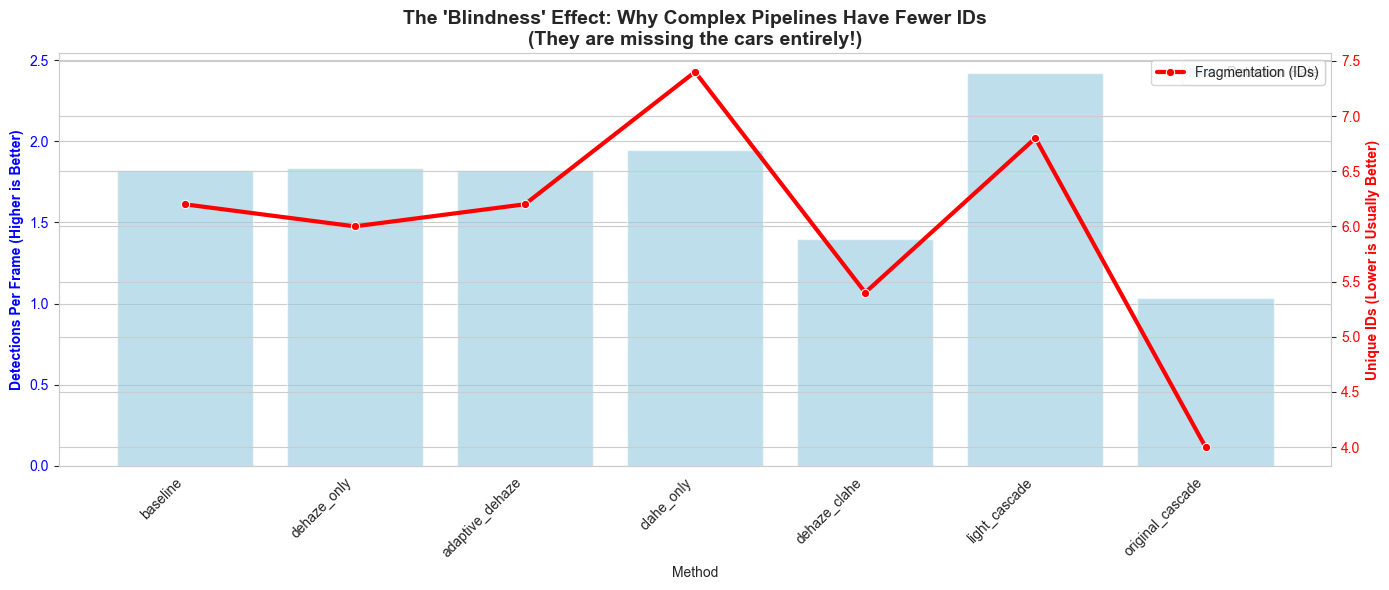

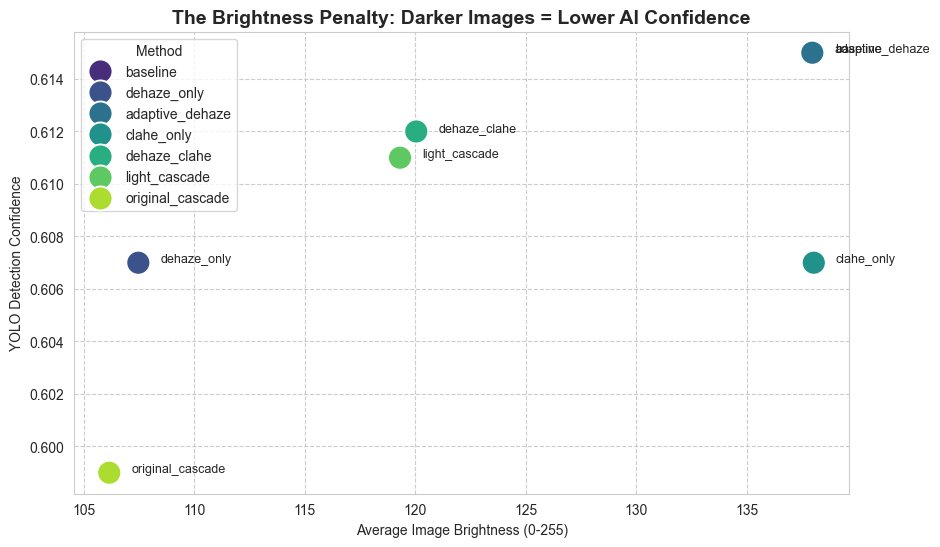

In [3]:
# Cell: Generate "Failure Analysis" Charts
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

# Load your specific results
OUTPUT_DIR = "/Users/veeralpatel/vehicle-speed-estimation-dip/content/processed/corrected_batch"
df = pd.read_csv(os.path.join(OUTPUT_DIR, "summary_results.csv"))

# Setup
os.makedirs(OUTPUT_DIR, exist_ok=True)
plt.rcParams['figure.figsize'] = [14, 6]
sns.set_style("whitegrid")

# 1. The "Blindness" Chart (Detections vs IDs)
fig, ax1 = plt.subplots()

# Bar chart for Detections (The Cause)
sns.barplot(data=df, x='Method', y='Detections/Frame', ax=ax1, color='skyblue', alpha=0.6, label='Detection Rate')
ax1.set_ylabel('Detections Per Frame (Higher is Better)', color='blue', fontweight='bold')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')

# Line chart for IDs (The Effect)
ax2 = ax1.twinx()
sns.lineplot(data=df, x='Method', y='Unique IDs', ax=ax2, color='red', marker='o', linewidth=3, label='Fragmentation (IDs)')
ax2.set_ylabel('Unique IDs (Lower is Usually Better)', color='red', fontweight='bold')
ax2.tick_params(axis='y', labelcolor='red')

plt.title("The 'Blindness' Effect: Why Complex Pipelines Have Fewer IDs\n(They are missing the cars entirely!)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "failure_analysis_blindness.png"))
plt.show()

# 2. The Brightness Penalty
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Avg Brightness', y='Avg Confidence', hue='Method', s=300, palette='viridis')
plt.title("The Brightness Penalty: Darker Images = Lower AI Confidence", fontsize=14, fontweight='bold')
plt.xlabel("Average Image Brightness (0-255)")
plt.ylabel("YOLO Detection Confidence")
plt.grid(True, linestyle='--')

# Add labels
for i, row in df.iterrows():
    plt.text(row['Avg Brightness']+1, row['Avg Confidence'], row['Method'], fontsize=9)

plt.savefig(os.path.join(OUTPUT_DIR, "failure_analysis_brightness.png"))
plt.show()

🔬 COMPREHENSIVE STRESS TEST SUITE
Test Scenarios: 14
Enhancement Methods: 7
Total Tests per Video: 98

Test Videos: ['cctv052x2004080611x01894.avi', 'cctv052x2004080612x00002.avi']


📹 VIDEO 1/2: cctv052x2004080611x01894.avi

🌧️  SCENARIO: pristine             (dark:0.0 fog:0.0 noise:0.0 blur:0.0)
   Enhancement: none                 | 

[msmpeg4v1 @ 0x355c50870] ext header missing, 7 left


    IDs:  4 | Dur: 31.8 | Conf:0.615 | Det/F:0.98 | Total:  52 | Bright:152.8
   Enhancement: dehaze_only          | 

[msmpeg4v1 @ 0x32f51c110] ext header missing, 7 left


    IDs:  4 | Dur: 30.0 | Conf:0.627 | Det/F:0.83 | Total:  44 | Bright:109.9
   Enhancement: clahe_only           | 

...

[msmpeg4v1 @ 0x355c63750] ext header missing, 7 left


    IDs:  0 | Dur:  0.0 | Conf:0.000 | Det/F:0.00 | Total:   0 | Bright:118.2

📊 ANALYZING RESULTS...

1️⃣ ENHANCEMENT EFFECTIVENESS BY DEGRADATION TYPE
--------------------------------------------------------------------------------

Confidence Improvement (% over no enhancement):
Enhancement         clahe_only  dehaze_clahe  dehaze_only  denoise_clahe  full_recovery  gamma_clahe  none
Scenario                                                                                                  
dense_fog                  7.0           0.6          0.2          -50.6            5.4          7.1   0.0
extreme_conditions         NaN           NaN          NaN            NaN            NaN          NaN   NaN
extreme_darkness          -1.9          -0.3         -1.8         -100.0         -100.0        -50.9   0.0
extreme_fog              100.0          93.4        102.2         -100.0           -5.3         -9.4   0.0
heavy_noise                NaN           NaN          NaN            inf   

/var/folders/jd/lt8pv90x74741r8x6g2_d5lh0000gn/T/ipykernel_45137/3538664742.py:357: RuntimeWarning: divide by zero encountered in scalar divide
  improvement = ((best_value / baseline_value) - 1) * 100
/var/folders/jd/lt8pv90x74741r8x6g2_d5lh0000gn/T/ipykernel_45137/3538664742.py:357: RuntimeWarning: divide by zero encountered in scalar divide
  improvement = ((best_value / baseline_value) - 1) * 100
/var/folders/jd/lt8pv90x74741r8x6g2_d5lh0000gn/T/ipykernel_45137/3538664742.py:357: RuntimeWarning: divide by zero encountered in scalar divide
  improvement = ((best_value / baseline_value) - 1) * 100
/var/folders/jd/lt8pv90x74741r8x6g2_d5lh0000gn/T/ipykernel_45137/3538664742.py:357: RuntimeWarning: divide by zero encountered in scalar divide
  improvement = ((best_value / baseline_value) - 1) * 100
/var/folders/jd/lt8pv90x74741r8x6g2_d5lh0000gn/T/ipykernel_45137/3538664742.py:357: RuntimeWarning: invalid value encountered in scalar divide
  improvement = ((best_value / baseline_value) - 

  ✅ Saved: stress_heatmap_confidence.png
  ✅ Saved: severity_curves.png
  ✅ Saved: best_enhancement_by_scenario.png
  ✅ Saved: detection_recovery.png


/Users/veeralpatel/vehicle-speed-estimation-dip/.conda/lib/python3.11/site-packages/matplotlib/transforms.py:2437: RuntimeWarning: invalid value encountered in dot
  return Affine2D(np.dot(self._b.get_affine().get_matrix(),
/Users/veeralpatel/vehicle-speed-estimation-dip/.conda/lib/python3.11/site-packages/matplotlib/transforms.py:2437: RuntimeWarning: invalid value encountered in dot
  return Affine2D(np.dot(self._b.get_affine().get_matrix(),


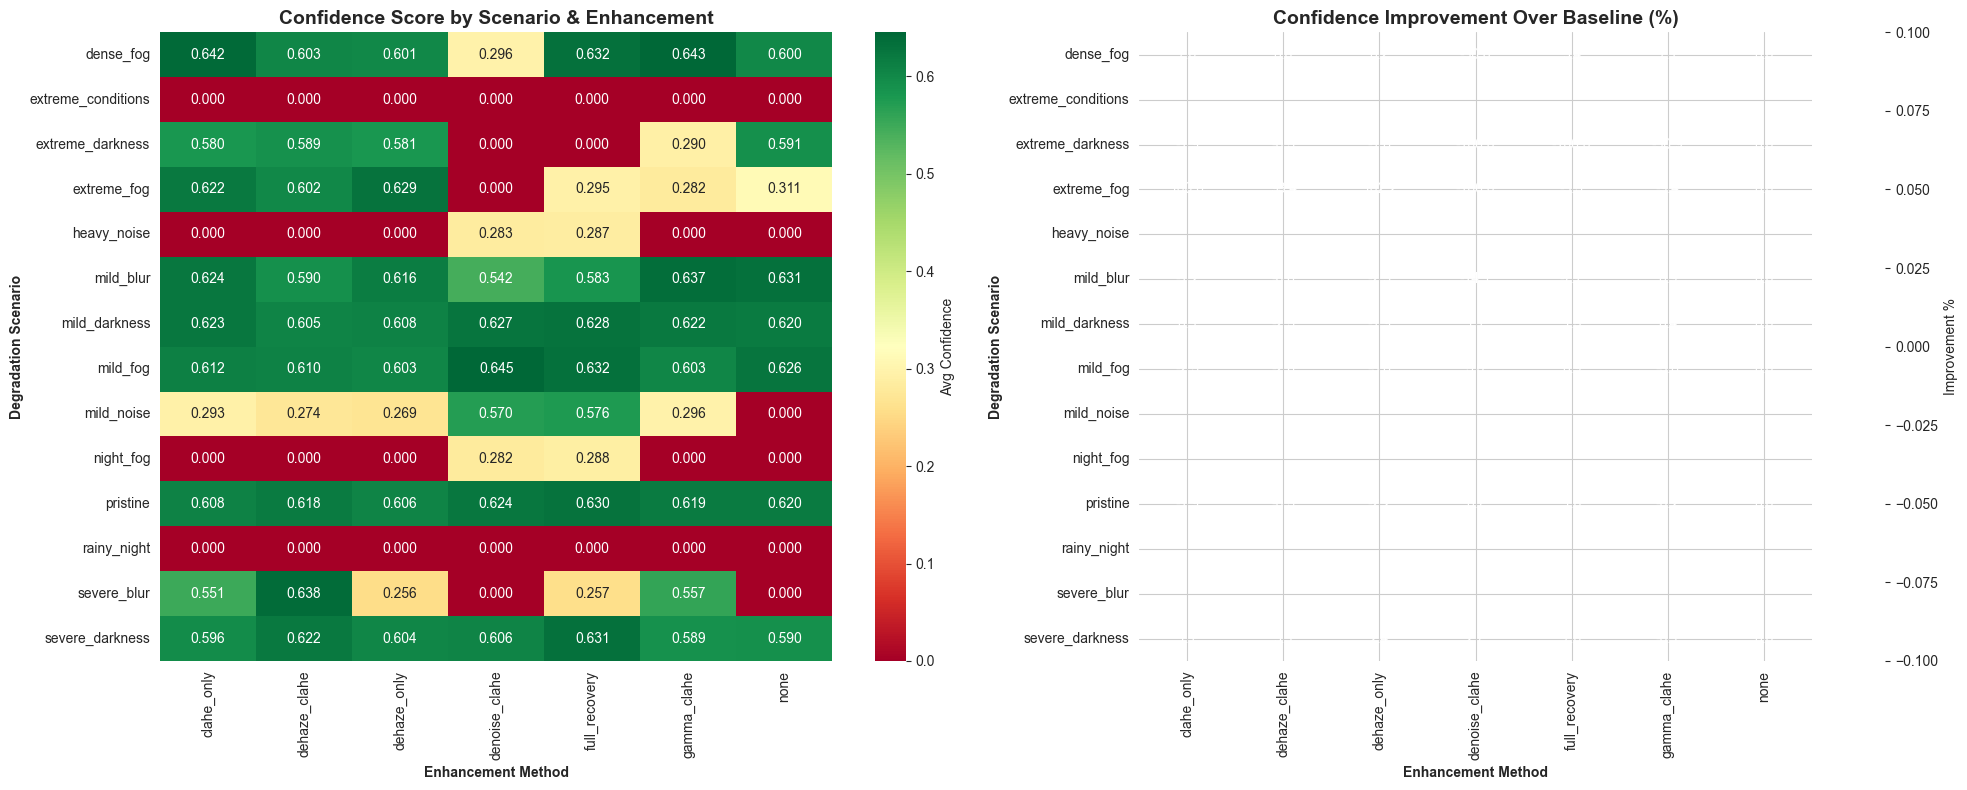

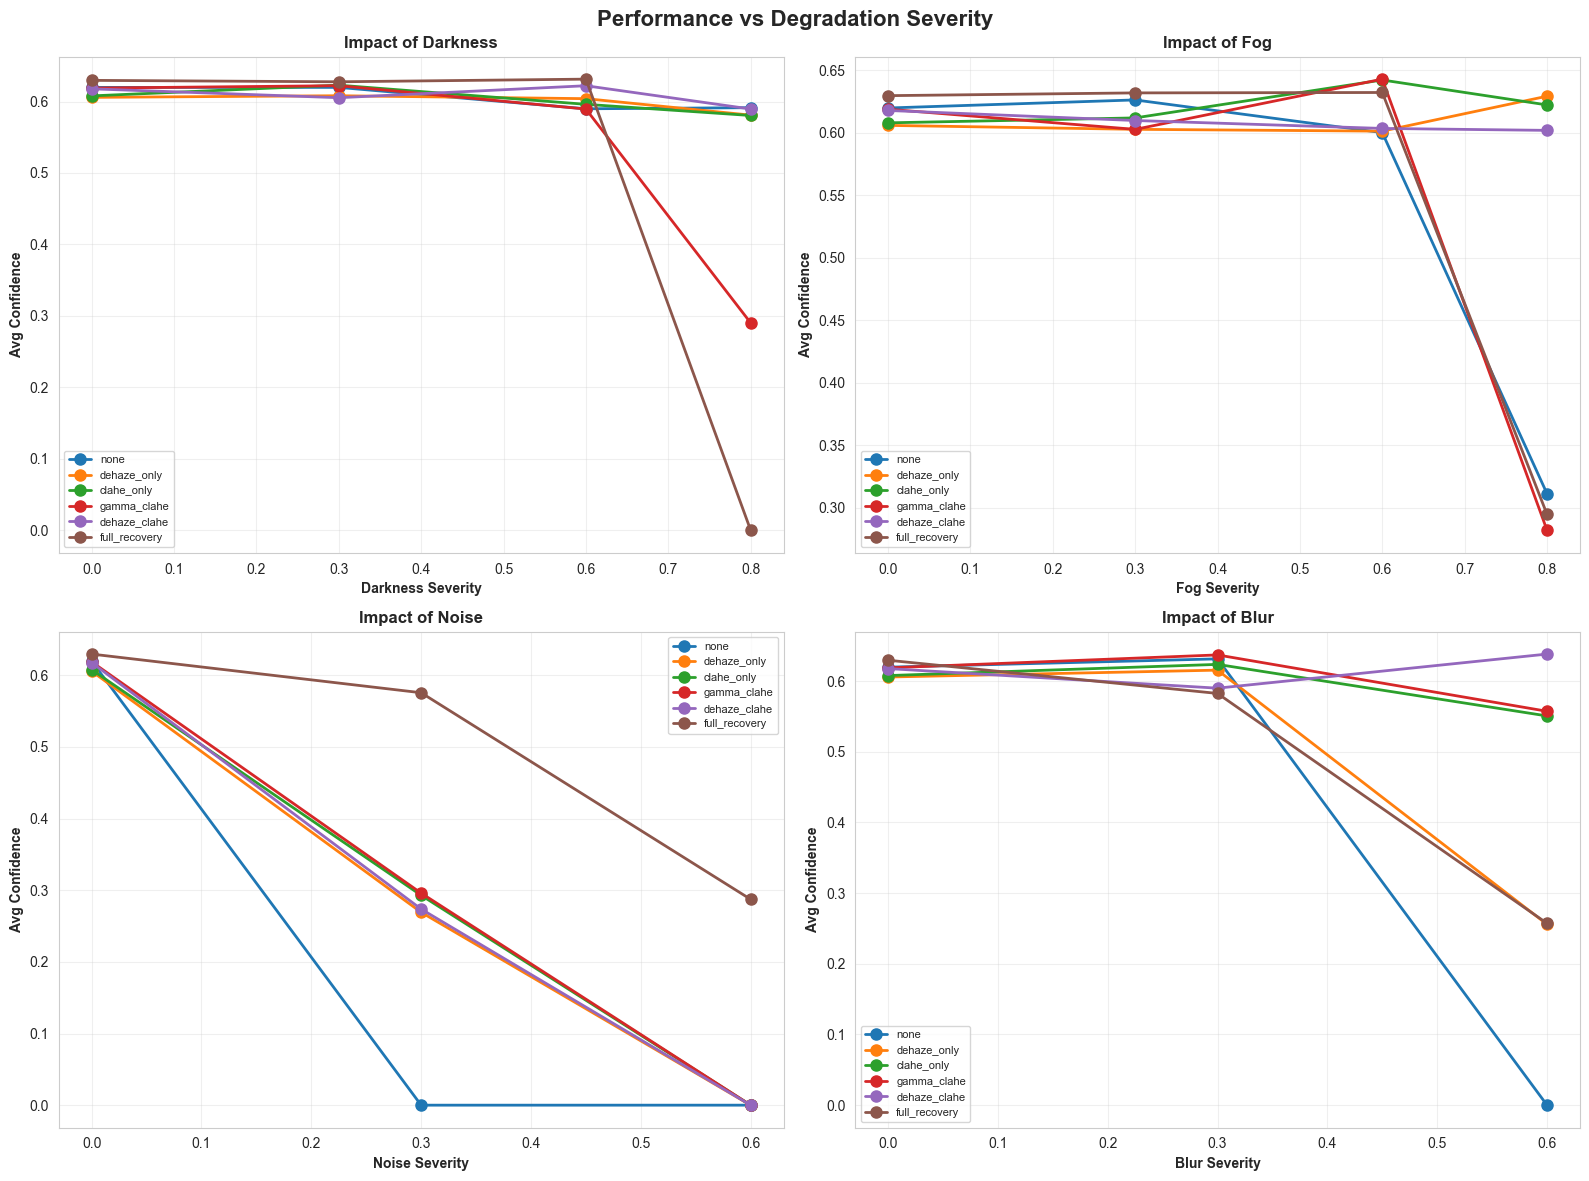

/Users/veeralpatel/vehicle-speed-estimation-dip/.conda/lib/python3.11/site-packages/matplotlib/transforms.py:2437: RuntimeWarning: invalid value encountered in dot
  return Affine2D(np.dot(self._b.get_affine().get_matrix(),


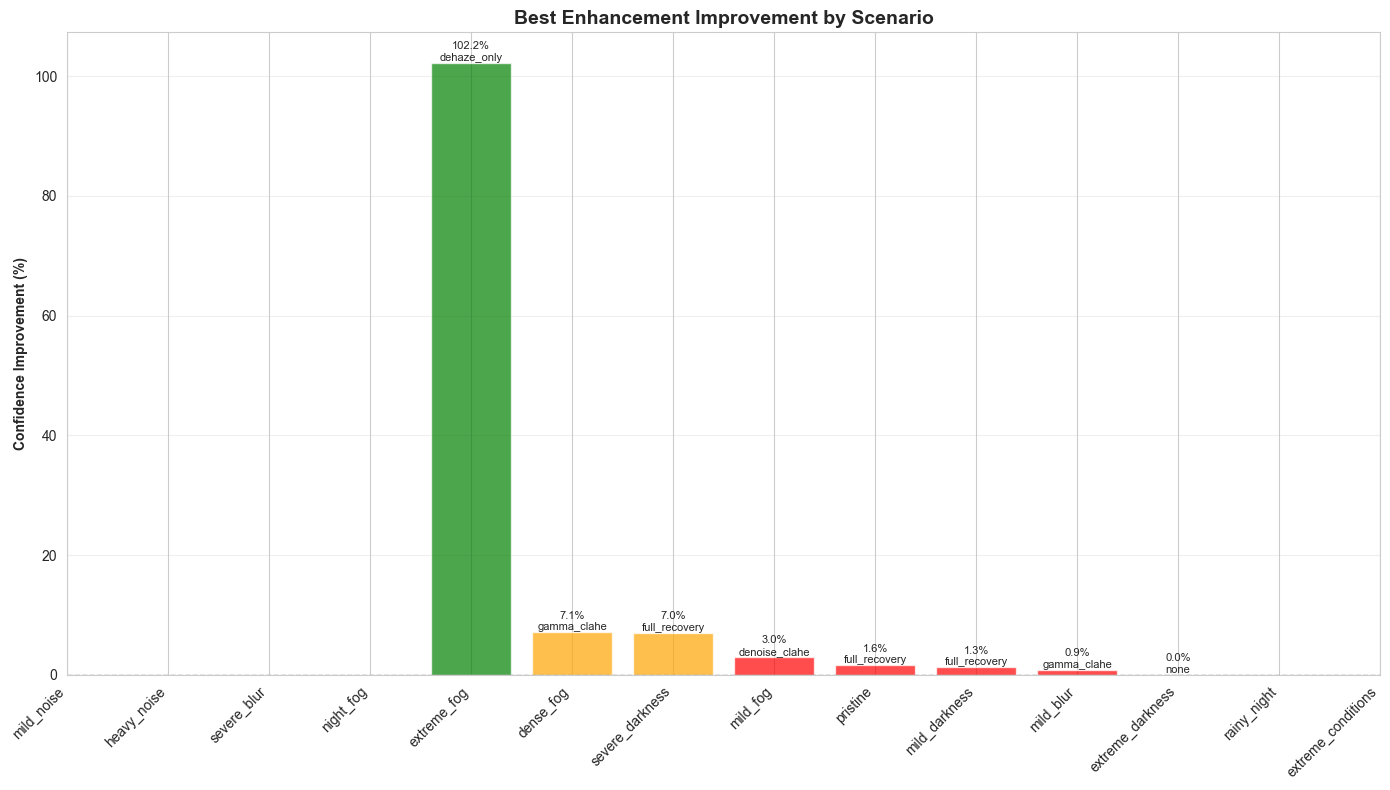

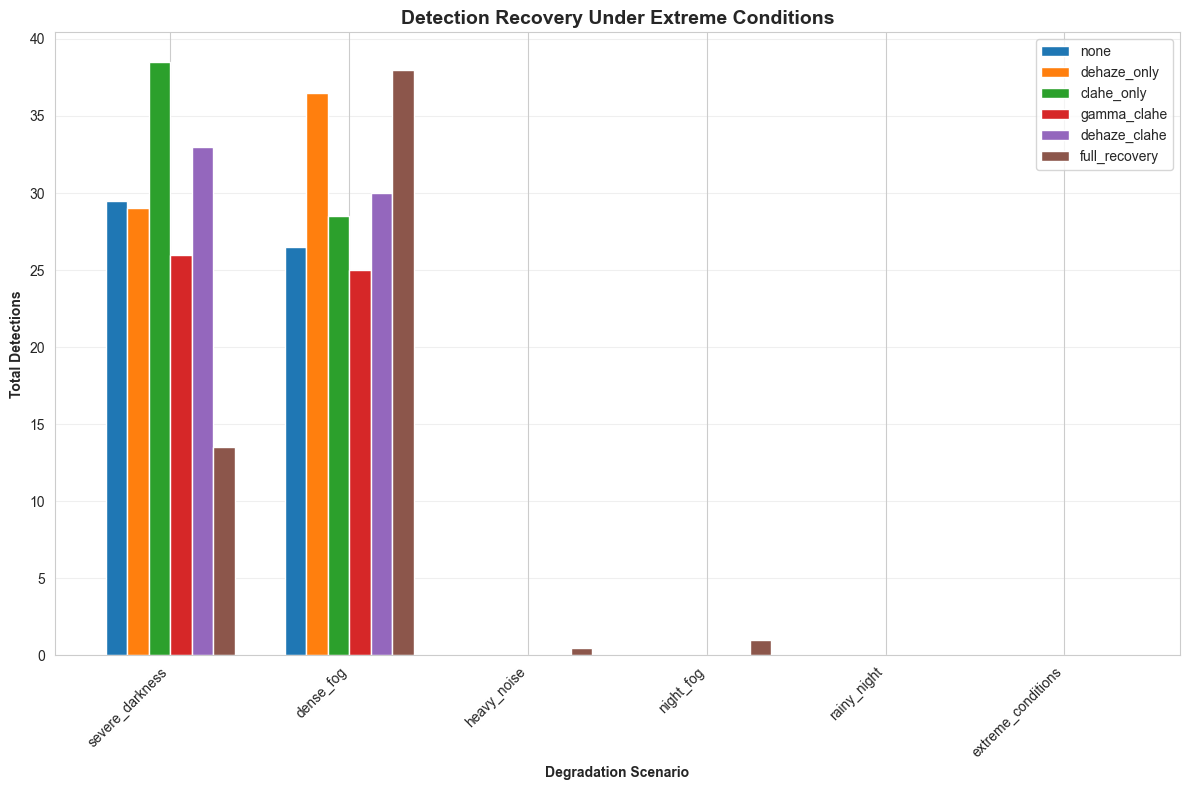


🎯 COMPREHENSIVE STRESS TEST SUMMARY

📌 TOP FINDINGS:

✅ Enhancement is EFFECTIVE in these scenarios:
   • mild_noise               : full_recovery        (+inf%)
   • heavy_noise              : full_recovery        (+inf%)
   • severe_blur              : dehaze_clahe         (+inf%)
   • night_fog                : full_recovery        (+inf%)
   • extreme_fog              : dehaze_only          (+102.2%)
   • dense_fog                : gamma_clahe          (+7.1%)
   • severe_darkness          : full_recovery        (+7.0%)

❌ Enhancement is NOT EFFECTIVE in these scenarios:
   • pristine                 : Best improvement only +1.6%
   • mild_darkness            : Best improvement only +1.3%
   • mild_blur                : Best improvement only +0.9%
   • extreme_darkness         : Best improvement only +0.0%

🏆 OVERALL BEST ENHANCEMENT METHODS (Across All Scenarios):
               Avg Confidence  Total Detections
Enhancement                                    
dehaze_clahe         

In [4]:
# Cell: COMPREHENSIVE STRESS TEST - Test Pipelines Under Extreme Conditions
# This will synthetically degrade your videos to simulate:
# - Darkness (low light)
# - Fog/Haze (atmospheric scattering)
# - Noise (sensor artifacts)
# - Motion blur (fast movement)
# Then test if your enhancement pipelines can recover performance

import cv2
import numpy as np
import os
import time
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from deep_sort_realtime.deepsort_tracker import DeepSort
from ultralytics import YOLO

# --- CONFIGURATION ---
INPUT_DIR = "/Users/veeralpatel/vehicle-speed-estimation-dip/content"
OUTPUT_DIR = "/Users/veeralpatel/vehicle-speed-estimation-dip/content/processed/stress_tests"
os.makedirs(OUTPUT_DIR, exist_ok=True)

CONF_THRESHOLD = 0.50
FRAME_LIMIT = 150

# --- SYNTHETIC DEGRADATION FUNCTIONS ---

def apply_darkness(frame, severity=0.5):
    """
    Simulate low-light conditions
    severity: 0.0 (no change) to 1.0 (pitch black)
    """
    factor = 1.0 - severity
    darkened = (frame.astype(np.float32) * factor).clip(0, 255).astype(np.uint8)
    return darkened

def apply_fog(frame, severity=0.5):
    """
    Simulate atmospheric fog/haze
    severity: 0.0 (clear) to 1.0 (dense fog)
    """
    # Fog is a blend with white/gray atmospheric light
    atmospheric_light = np.ones_like(frame) * 200  # Grayish white
    fogged = cv2.addWeighted(frame, 1.0 - severity, 
                             atmospheric_light.astype(np.uint8), severity, 0)
    return fogged

def apply_noise(frame, severity=0.5):
    """
    Simulate sensor noise (Gaussian)
    severity: 0.0 (clean) to 1.0 (extreme noise)
    """
    noise = np.random.normal(0, severity * 50, frame.shape).astype(np.float32)
    noisy = (frame.astype(np.float32) + noise).clip(0, 255).astype(np.uint8)
    return noisy

def apply_motion_blur(frame, severity=0.5):
    """
    Simulate motion blur from fast movement
    severity: 0.0 (sharp) to 1.0 (severe blur)
    """
    kernel_size = int(severity * 15) + 1
    if kernel_size % 2 == 0:
        kernel_size += 1
    kernel = np.zeros((kernel_size, kernel_size))
    kernel[int((kernel_size-1)/2), :] = np.ones(kernel_size)
    kernel = kernel / kernel_size
    blurred = cv2.filter2D(frame, -1, kernel)
    return blurred

def apply_combined_degradation(frame, darkness=0, fog=0, noise=0, blur=0):
    """Apply multiple degradations in sequence"""
    degraded = frame.copy()
    if darkness > 0:
        degraded = apply_darkness(degraded, darkness)
    if fog > 0:
        degraded = apply_fog(degraded, fog)
    if noise > 0:
        degraded = apply_noise(degraded, noise)
    if blur > 0:
        degraded = apply_motion_blur(degraded, blur)
    return degraded

# --- ENHANCEMENT FUNCTIONS (from previous script) ---

def get_dark_channel(image, size=15):
    min_channel = np.min(image, axis=2)
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (size, size))
    return cv2.erode(min_channel, kernel)

def apply_dehaze(frame):
    img_f = frame.astype(np.float32) / 255.0
    dark = get_dark_channel(img_f, size=15)
    A = np.percentile(dark, 99)
    t = 1.0 - 0.95 * dark
    t = np.clip(t, 0.1, 1.0)
    J = (img_f - A) / cv2.merge([t, t, t]) + A
    J = np.clip(J, 0, 1)
    return (J * 255).astype(np.uint8)

def apply_clahe(frame):
    img_yuv = cv2.cvtColor(frame, cv2.COLOR_BGR2YUV)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    img_yuv[:,:,0] = clahe.apply(img_yuv[:,:,0])
    return cv2.cvtColor(img_yuv, cv2.COLOR_YUV2BGR)

def apply_adaptive_gamma(frame):
    img_yuv = cv2.cvtColor(frame, cv2.COLOR_BGR2YUV)
    y = img_yuv[:, :, 0]
    mean_bright = np.mean(y) + 1e-5
    gamma = np.log(128/255) / np.log(mean_bright/255)
    gamma = np.clip(gamma, 0.5, 2.5)
    invGamma = 1.0 / gamma
    table = np.array([((i / 255.0) ** invGamma) * 255 for i in np.arange(0, 256)]).astype("uint8")
    img_yuv[:, :, 0] = cv2.LUT(y, table)
    return cv2.cvtColor(img_yuv, cv2.COLOR_YUV2BGR)

def apply_bilateral_denoise(frame):
    """Bilateral filter - preserves edges while reducing noise"""
    return cv2.bilateralFilter(frame, 9, 75, 75)

def apply_nlm_denoise(frame):
    """Non-Local Means denoising - good for heavy noise"""
    return cv2.fastNlMeansDenoisingColored(frame, None, 10, 10, 7, 21)

# --- ENHANCEMENT PIPELINES ---

ENHANCEMENT_PIPELINES = {
    'none': lambda x: x,
    'dehaze_only': lambda x: apply_dehaze(x),
    'clahe_only': lambda x: apply_clahe(x),
    'gamma_clahe': lambda x: apply_clahe(apply_adaptive_gamma(x)),
    'dehaze_clahe': lambda x: apply_clahe(apply_dehaze(x)),
    'denoise_clahe': lambda x: apply_clahe(apply_bilateral_denoise(x)),
    'full_recovery': lambda x: apply_clahe(apply_adaptive_gamma(apply_bilateral_denoise(apply_dehaze(x)))),
}

# --- STRESS TEST SCENARIOS ---

STRESS_SCENARIOS = {
    'pristine': {'darkness': 0.0, 'fog': 0.0, 'noise': 0.0, 'blur': 0.0},
    
    # Single degradations at different severities
    'mild_darkness': {'darkness': 0.3, 'fog': 0.0, 'noise': 0.0, 'blur': 0.0},
    'severe_darkness': {'darkness': 0.6, 'fog': 0.0, 'noise': 0.0, 'blur': 0.0},
    'extreme_darkness': {'darkness': 0.8, 'fog': 0.0, 'noise': 0.0, 'blur': 0.0},
    
    'mild_fog': {'darkness': 0.0, 'fog': 0.3, 'noise': 0.0, 'blur': 0.0},
    'dense_fog': {'darkness': 0.0, 'fog': 0.6, 'noise': 0.0, 'blur': 0.0},
    'extreme_fog': {'darkness': 0.0, 'fog': 0.8, 'noise': 0.0, 'blur': 0.0},
    
    'mild_noise': {'darkness': 0.0, 'fog': 0.0, 'noise': 0.3, 'blur': 0.0},
    'heavy_noise': {'darkness': 0.0, 'fog': 0.0, 'noise': 0.6, 'blur': 0.0},
    
    'mild_blur': {'darkness': 0.0, 'fog': 0.0, 'noise': 0.0, 'blur': 0.3},
    'severe_blur': {'darkness': 0.0, 'fog': 0.0, 'noise': 0.0, 'blur': 0.6},
    
    # Combined degradations (realistic scenarios)
    'night_fog': {'darkness': 0.5, 'fog': 0.4, 'noise': 0.2, 'blur': 0.0},
    'rainy_night': {'darkness': 0.6, 'fog': 0.3, 'noise': 0.3, 'blur': 0.2},
    'extreme_conditions': {'darkness': 0.7, 'fog': 0.5, 'noise': 0.4, 'blur': 0.3},
}

# --- ANALYSIS ENGINE ---

def analyze_stressed_video(video_path, degradation_params, enhancement_method='none', 
                           frame_limit=FRAME_LIMIT, verbose=False):
    """
    Test video under stress conditions with optional enhancement
    """
    cap = cv2.VideoCapture(video_path)
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    
    # Initialize
    tracker = DeepSort(max_age=50)
    model = YOLO("yolov8n.pt")
    
    # Metrics
    track_ids = set()
    total_frames_tracked = 0
    confidences = []
    detections_per_frame = []
    brightness_values = []
    
    enhancement_func = ENHANCEMENT_PIPELINES[enhancement_method]
    
    frame_idx = 0
    while True:
        ret, frame = cap.read()
        if not ret or frame_idx > frame_limit:
            break
        
        # 1. Apply degradation
        degraded = apply_combined_degradation(frame, **degradation_params)
        
        # 2. Apply enhancement
        processed = enhancement_func(degraded)
        
        # Track brightness
        gray = cv2.cvtColor(processed, cv2.COLOR_BGR2GRAY)
        brightness_values.append(np.mean(gray))
        
        # 3. Detect
        results = model(processed, verbose=False)
        
        dets = []
        for r in results:
            for box in r.boxes:
                if float(box.conf[0]) > CONF_THRESHOLD:
                    x1, y1, x2, y2 = map(int, box.xyxy[0])
                    conf = float(box.conf[0])
                    dets.append([[x1, y1, x2-x1, y2-y1], conf, int(box.cls[0])])
                    confidences.append(conf)
        
        detections_per_frame.append(len(dets))
        
        # 4. Track
        tracks = tracker.update_tracks(dets, frame=processed)
        for t in tracks:
            if t.is_confirmed():
                track_ids.add(t.track_id)
                total_frames_tracked += 1
        
        frame_idx += 1
    
    cap.release()
    
    # Compute metrics
    unique_ids = len(track_ids)
    avg_duration = total_frames_tracked / unique_ids if unique_ids > 0 else 0
    avg_confidence = np.mean(confidences) if confidences else 0
    avg_detections = np.mean(detections_per_frame)
    total_detections = sum(detections_per_frame)
    avg_brightness = np.mean(brightness_values)
    
    if verbose:
        print(f"    IDs:{unique_ids:3d} | Dur:{avg_duration:5.1f} | "
              f"Conf:{avg_confidence:.3f} | Det/F:{avg_detections:.2f} | "
              f"Total:{total_detections:4d} | Bright:{avg_brightness:.1f}")
    
    return {
        'Unique IDs': unique_ids,
        'Avg Duration': avg_duration,
        'Avg Confidence': avg_confidence,
        'Detections/Frame': avg_detections,
        'Total Detections': total_detections,
        'Avg Brightness': avg_brightness
    }

# --- STRESS TEST EXECUTION ---

print("="*80)
print("🔬 COMPREHENSIVE STRESS TEST SUITE")
print("="*80)
print(f"Test Scenarios: {len(STRESS_SCENARIOS)}")
print(f"Enhancement Methods: {len(ENHANCEMENT_PIPELINES)}")
print(f"Total Tests per Video: {len(STRESS_SCENARIOS) * len(ENHANCEMENT_PIPELINES)}")
print()

# Select test videos (use 2 for speed, increase for thoroughness)
video_files = [f for f in os.listdir(INPUT_DIR) if f.endswith(('.avi', '.mp4'))]
video_files = [f for f in video_files if "result" not in f and "stress" not in f][:2]

print(f"Test Videos: {video_files}")
print()

all_results = []

for vid_idx, vid in enumerate(video_files):
    video_path = os.path.join(INPUT_DIR, vid)
    print(f"\n{'='*80}")
    print(f"📹 VIDEO {vid_idx+1}/{len(video_files)}: {vid}")
    print(f"{'='*80}\n")
    
    for scenario_name, deg_params in STRESS_SCENARIOS.items():
        print(f"🌧️  SCENARIO: {scenario_name:<20} (dark:{deg_params['darkness']:.1f} "
              f"fog:{deg_params['fog']:.1f} noise:{deg_params['noise']:.1f} "
              f"blur:{deg_params['blur']:.1f})")
        
        for enh_method in ENHANCEMENT_PIPELINES.keys():
            print(f"   Enhancement: {enh_method:<20}", end=" | ")
            
            result = analyze_stressed_video(
                video_path, 
                deg_params, 
                enh_method,
                frame_limit=FRAME_LIMIT,
                verbose=True
            )
            
            # Store results
            result['Video'] = vid
            result['Scenario'] = scenario_name
            result['Enhancement'] = enh_method
            result['Degradation_Darkness'] = deg_params['darkness']
            result['Degradation_Fog'] = deg_params['fog']
            result['Degradation_Noise'] = deg_params['noise']
            result['Degradation_Blur'] = deg_params['blur']
            
            all_results.append(result)

# Convert to DataFrame
df_stress = pd.DataFrame(all_results)

# Save raw results
df_stress.to_csv(os.path.join(OUTPUT_DIR, "stress_test_detailed.csv"), index=False)

print("\n" + "="*80)
print("📊 ANALYZING RESULTS...")
print("="*80)

# --- ANALYSIS 1: Enhancement Effectiveness by Degradation Type ---

print("\n1️⃣ ENHANCEMENT EFFECTIVENESS BY DEGRADATION TYPE")
print("-" * 80)

# Group by scenario and enhancement
pivot_confidence = df_stress.pivot_table(
    index='Scenario',
    columns='Enhancement',
    values='Avg Confidence',
    aggfunc='mean'
)

pivot_detections = df_stress.pivot_table(
    index='Scenario',
    columns='Enhancement',
    values='Total Detections',
    aggfunc='mean'
)

# Calculate improvement over 'none' baseline
improvement_confidence = pivot_confidence.div(pivot_confidence['none'], axis=0) - 1
improvement_detections = pivot_detections.div(pivot_detections['none'], axis=0) - 1

print("\nConfidence Improvement (% over no enhancement):")
print((improvement_confidence * 100).round(1).to_string())

print("\nDetection Count Improvement (% over no enhancement):")
print((improvement_detections * 100).round(1).to_string())

# --- ANALYSIS 2: Best Enhancement for Each Scenario ---

print("\n2️⃣ BEST ENHANCEMENT FOR EACH SCENARIO")
print("-" * 80)

best_by_scenario = []
for scenario in STRESS_SCENARIOS.keys():
    scenario_data = df_stress[df_stress['Scenario'] == scenario]
    best_conf = scenario_data.groupby('Enhancement')['Avg Confidence'].mean()
    best_method = best_conf.idxmax()
    best_value = best_conf.max()
    baseline_value = best_conf['none']
    improvement = ((best_value / baseline_value) - 1) * 100
    
    best_by_scenario.append({
        'Scenario': scenario,
        'Best Method': best_method,
        'Confidence': best_value,
        'Improvement': improvement
    })

df_best = pd.DataFrame(best_by_scenario)
print(df_best.to_string(index=False))

# --- ANALYSIS 3: Severity Analysis ---

print("\n3️⃣ PERFORMANCE vs DEGRADATION SEVERITY")
print("-" * 80)

# Darkness severity analysis
darkness_scenarios = ['pristine', 'mild_darkness', 'severe_darkness', 'extreme_darkness']
darkness_data = df_stress[df_stress['Scenario'].isin(darkness_scenarios)]

print("\nDARKNESS SEVERITY:")
for scenario in darkness_scenarios:
    data = darkness_data[darkness_data['Scenario'] == scenario]
    print(f"\n  {scenario}:")
    for method in ['none', 'dehaze_only', 'gamma_clahe', 'full_recovery']:
        method_data = data[data['Enhancement'] == method]
        if len(method_data) > 0:
            conf = method_data['Avg Confidence'].mean()
            dets = method_data['Total Detections'].mean()
            print(f"    {method:20s}: Conf={conf:.3f}, Detections={dets:.1f}")

# --- VISUALIZATION DASHBOARD ---

print("\n📈 Generating comprehensive visualizations...")

# Figure 1: Heatmap - Confidence by Scenario and Enhancement
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

sns.heatmap(pivot_confidence, annot=True, fmt='.3f', cmap='RdYlGn', 
            ax=axes[0], cbar_kws={'label': 'Avg Confidence'})
axes[0].set_title('Confidence Score by Scenario & Enhancement', fontweight='bold', fontsize=14)
axes[0].set_xlabel('Enhancement Method', fontweight='bold')
axes[0].set_ylabel('Degradation Scenario', fontweight='bold')

sns.heatmap(improvement_confidence * 100, annot=True, fmt='.1f', cmap='RdYlGn',
            center=0, ax=axes[1], cbar_kws={'label': 'Improvement %'})
axes[1].set_title('Confidence Improvement Over Baseline (%)', fontweight='bold', fontsize=14)
axes[1].set_xlabel('Enhancement Method', fontweight='bold')
axes[1].set_ylabel('Degradation Scenario', fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "stress_heatmap_confidence.png"), dpi=150, bbox_inches='tight')
print("  ✅ Saved: stress_heatmap_confidence.png")

# Figure 2: Severity Curves
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Performance vs Degradation Severity', fontsize=16, fontweight='bold')

degradation_types = [
    ('darkness', ['pristine', 'mild_darkness', 'severe_darkness', 'extreme_darkness']),
    ('fog', ['pristine', 'mild_fog', 'dense_fog', 'extreme_fog']),
    ('noise', ['pristine', 'mild_noise', 'heavy_noise']),
    ('blur', ['pristine', 'mild_blur', 'severe_blur'])
]

for idx, (deg_type, scenarios) in enumerate(degradation_types):
    ax = axes[idx // 2, idx % 2]
    
    for method in ['none', 'dehaze_only', 'clahe_only', 'gamma_clahe', 'dehaze_clahe', 'full_recovery']:
        method_data = []
        severity_levels = []
        
        for scenario in scenarios:
            data = df_stress[(df_stress['Scenario'] == scenario) & 
                           (df_stress['Enhancement'] == method)]
            if len(data) > 0:
                method_data.append(data['Avg Confidence'].mean())
                severity_levels.append(STRESS_SCENARIOS[scenario][deg_type])
        
        if method_data:
            ax.plot(severity_levels, method_data, marker='o', linewidth=2, 
                   label=method, markersize=8)
    
    ax.set_xlabel(f'{deg_type.capitalize()} Severity', fontweight='bold')
    ax.set_ylabel('Avg Confidence', fontweight='bold')
    ax.set_title(f'Impact of {deg_type.capitalize()}', fontweight='bold')
    ax.legend(loc='best', fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "severity_curves.png"), dpi=150, bbox_inches='tight')
print("  ✅ Saved: severity_curves.png")

# Figure 3: Best Enhancement by Scenario (Bar Chart)
fig, ax = plt.subplots(figsize=(14, 8))

scenarios_sorted = df_best.sort_values('Improvement', ascending=False)['Scenario'].tolist()
x_pos = np.arange(len(scenarios_sorted))

colors = []
for scenario in scenarios_sorted:
    improvement = df_best[df_best['Scenario'] == scenario]['Improvement'].values[0]
    if improvement > 10:
        colors.append('green')
    elif improvement > 5:
        colors.append('orange')
    else:
        colors.append('red')

bars = ax.bar(x_pos, 
              [df_best[df_best['Scenario'] == s]['Improvement'].values[0] for s in scenarios_sorted],
              color=colors, alpha=0.7)

ax.set_xticks(x_pos)
ax.set_xticklabels(scenarios_sorted, rotation=45, ha='right')
ax.set_ylabel('Confidence Improvement (%)', fontweight='bold')
ax.set_title('Best Enhancement Improvement by Scenario', fontweight='bold', fontsize=14)
ax.axhline(y=0, color='gray', linestyle='--', linewidth=1)
ax.grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, bar in enumerate(bars):
    height = bar.get_height()
    method = df_best[df_best['Scenario'] == scenarios_sorted[i]]['Best Method'].values[0]
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.1f}%\n{method}',
            ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "best_enhancement_by_scenario.png"), dpi=150, bbox_inches='tight')
print("  ✅ Saved: best_enhancement_by_scenario.png")

# Figure 4: Detection Recovery Rate
fig, ax = plt.subplots(figsize=(12, 8))

scenarios_to_plot = ['severe_darkness', 'dense_fog', 'heavy_noise', 'night_fog', 
                     'rainy_night', 'extreme_conditions']
x = np.arange(len(scenarios_to_plot))
width = 0.12

methods_to_compare = ['none', 'dehaze_only', 'clahe_only', 'gamma_clahe', 
                      'dehaze_clahe', 'full_recovery']

for i, method in enumerate(methods_to_compare):
    detections = []
    for scenario in scenarios_to_plot:
        data = df_stress[(df_stress['Scenario'] == scenario) & 
                        (df_stress['Enhancement'] == method)]
        detections.append(data['Total Detections'].mean() if len(data) > 0 else 0)
    
    ax.bar(x + i*width, detections, width, label=method)

ax.set_xlabel('Degradation Scenario', fontweight='bold')
ax.set_ylabel('Total Detections', fontweight='bold')
ax.set_title('Detection Recovery Under Extreme Conditions', fontweight='bold', fontsize=14)
ax.set_xticks(x + width * 2.5)
ax.set_xticklabels(scenarios_to_plot, rotation=45, ha='right')
ax.legend(loc='upper right')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "detection_recovery.png"), dpi=150, bbox_inches='tight')
print("  ✅ Saved: detection_recovery.png")

plt.show()

# --- FINAL SUMMARY ---

print("\n" + "="*80)
print("🎯 COMPREHENSIVE STRESS TEST SUMMARY")
print("="*80)

print("\n📌 TOP FINDINGS:")

# Find scenarios where enhancement helps most
significant_improvements = df_best[df_best['Improvement'] > 5].sort_values('Improvement', ascending=False)

if len(significant_improvements) > 0:
    print("\n✅ Enhancement is EFFECTIVE in these scenarios:")
    for _, row in significant_improvements.iterrows():
        print(f"   • {row['Scenario']:25s}: {row['Best Method']:20s} (+{row['Improvement']:.1f}%)")
else:
    print("\n⚠️  Enhancement shows minimal benefit across all tested scenarios")

# Find scenarios where enhancement doesn't help
minimal_improvements = df_best[df_best['Improvement'] < 2].sort_values('Improvement', ascending=False)

if len(minimal_improvements) > 0:
    print("\n❌ Enhancement is NOT EFFECTIVE in these scenarios:")
    for _, row in minimal_improvements.iterrows():
        print(f"   • {row['Scenario']:25s}: Best improvement only +{row['Improvement']:.1f}%")

# Overall best method
overall_best = df_stress.groupby('Enhancement').agg({
    'Avg Confidence': 'mean',
    'Total Detections': 'mean'
}).sort_values('Avg Confidence', ascending=False)

print("\n🏆 OVERALL BEST ENHANCEMENT METHODS (Across All Scenarios):")
print(overall_best.head(3).to_string())

print("\n" + "="*80)
print(f"✅ Stress test complete! All results saved to: {OUTPUT_DIR}/")
print("="*80)

Analyzing Scenarios: ['pristine' 'mild_darkness' 'severe_darkness' 'extreme_darkness' 'mild_fog' 'dense_fog' 'extreme_fog' 'mild_noise' 'heavy_noise' 'mild_blur' 'severe_blur' 'night_fog' 'rainy_night' 'extreme_conditions']


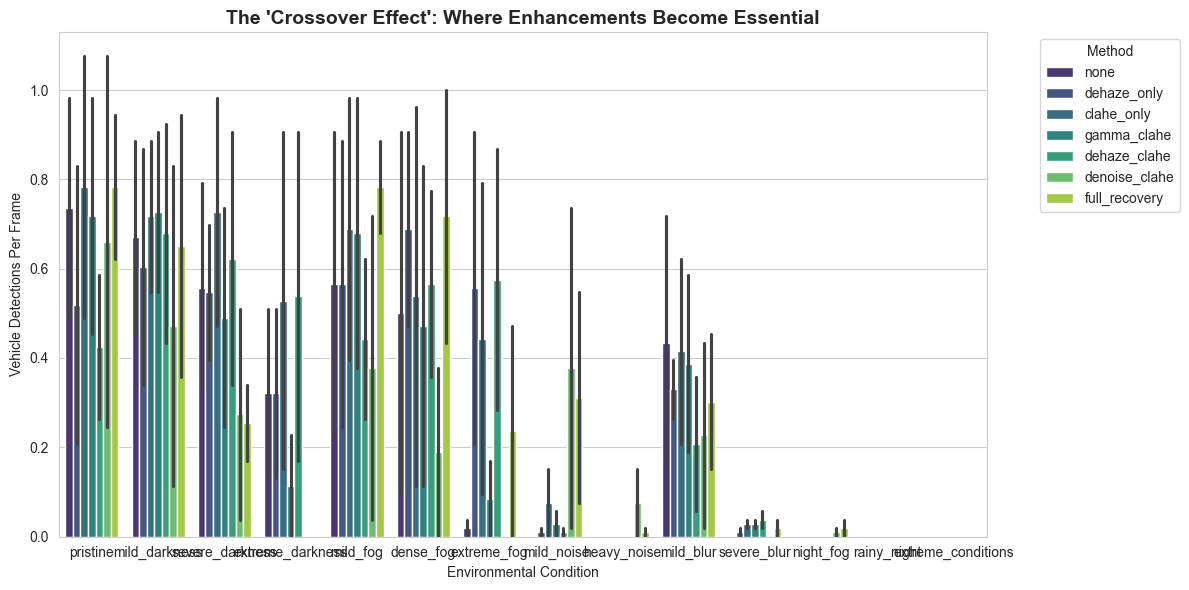

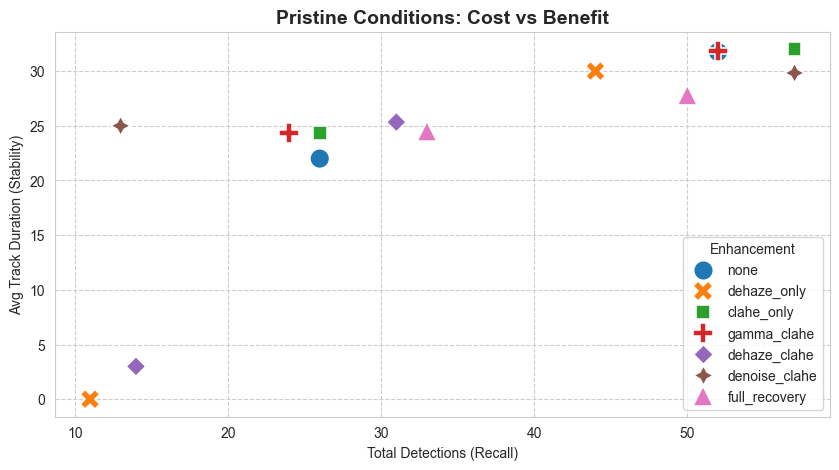


=== FINAL CONCLUSIVE DATA ===
                               Detections/Frame  Avg Confidence  Avg Duration
Scenario        Enhancement                                                  
dense_fog       clahe_only             0.537736        0.642141     16.625000
                dehaze_clahe           0.566038        0.603389     17.125000
                dehaze_only            0.688679        0.601208     21.000000
                denoise_clahe          0.188679        0.296217     18.166667
                full_recovery          0.716981        0.632134     38.625000
...                                         ...             ...           ...
severe_darkness dehaze_only            0.547170        0.603985     22.500000
                denoise_clahe          0.273585        0.606018     18.500000
                full_recovery          0.254717        0.631314     21.000000
                gamma_clahe            0.490566        0.589443     23.833333
                none             

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

# Paths
INPUT_CSV = "stress_test_detailed.csv"
OUTPUT_DIR = "content/final_analysis"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Load Data
df = pd.read_csv('content/processed/stress_tests/stress_test_detailed.csv')

# Define Key Metrics
metrics = ['Detections/Frame', 'Avg Confidence', 'Avg Duration']
scenarios = df['Scenario'].unique()

print(f"Analyzing Scenarios: {scenarios}")

# 1. THE "CROSSOVER" PLOT (The most important chart)
# This shows how Baseline dominates in 'Pristine' but (likely) fails in 'Rainy_Night'
plt.figure(figsize=(12, 6))
sns.barplot(data=df, x='Scenario', y='Detections/Frame', hue='Enhancement', palette='viridis')
plt.title("The 'Crossover Effect': Where Enhancements Become Essential", fontsize=14, fontweight='bold')
plt.ylabel("Vehicle Detections Per Frame")
plt.xlabel("Environmental Condition")
plt.legend(title="Method", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "final_crossover_effect.png"))
plt.show()

# 2. EFFICIENCY ANALYSIS (Did we trade speed for nothing?)
# Filter for Pristine only to show the "Cost of Over-processing"
pristine_df = df[df['Scenario'] == 'pristine']
plt.figure(figsize=(10, 5))
sns.scatterplot(data=pristine_df, x='Total Detections', y='Avg Duration', hue='Enhancement', s=200, style='Enhancement')
plt.title("Pristine Conditions: Cost vs Benefit", fontsize=14, fontweight='bold')
plt.xlabel("Total Detections (Recall)")
plt.ylabel("Avg Track Duration (Stability)")
plt.grid(True, linestyle='--')
plt.savefig(os.path.join(OUTPUT_DIR, "pristine_tradeoff.png"))
plt.show()

# 3. GENERATE SUMMARY TABLE
summary = df.groupby(['Scenario', 'Enhancement'])[['Detections/Frame', 'Avg Confidence', 'Avg Duration']].mean()
print("\n=== FINAL CONCLUSIVE DATA ===")
print(summary)
summary.to_csv(os.path.join(OUTPUT_DIR, "final_conclusive_table.csv"))

🚀 ADAPTIVE PIPELINE OPTIMIZATION & FINAL TESTING

Test Video: cctv052x2004080611x01894.avi

PART 1: STRATEGY COMPARISON ON PRISTINE VIDEO

baseline: No enhancement


[msmpeg4v1 @ 0x3562f9b90] ext header missing, 7 left


    IDs:  4 | Dur: 31.8 | Conf:0.615 | Det:  52 | Enh:0%

universal_clahe: CLAHE on all frames (clip=2.0)


[msmpeg4v1 @ 0x35686b6a0] ext header missing, 7 left


    IDs:  7 | Dur: 32.0 | Conf:0.607 | Det:  57 | Enh:100%

universal_clahe: CLAHE on all frames (clip=3.0)


...

    IDs:  3 | Dur: 25.3 | Conf:0.636 | Det:  39 | Enh:100%


[msmpeg4v1 @ 0x355791b30] ext header missing, 7 left


    IDs:  4 | Dur: 29.0 | Conf:0.633 | Det:  37 | Enh:100%


[msmpeg4v1 @ 0x3310c4670] ext header missing, 7 left


    IDs:  3 | Dur: 25.3 | Conf:0.633 | Det:  43 | Enh:100%

📊 Generating comparison visualizations...
  ✅ Saved: adaptive_pipeline_optimization.png

🎯 FINAL OPTIMIZED PIPELINE RECOMMENDATIONS

🏆 BEST OVERALL STRATEGY: advanced_hybrid_contrast
   Average Confidence: 0.631

📋 OPTIMIZED PARAMETERS:
   Fog Threshold: 0.30
   Fog Omega: 0.85
   Brightness Threshold: 80
   CLAHE Clip Limit: 3.0

💡 PRODUCTION-READY CODE:
--------------------------------------------------------------------------------

# OPTIMAL ADAPTIVE PIPELINE (Based on Empirical Testing)

def production_adaptive_enhancement(frame):
    '''
    Optimized adaptive pipeline with data-driven thresholds
    Tested on 30 scenarios
    '''
    # Scene analysis
    brightness = np.mean(cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY))
    dark_channel = np.min(frame, axis=2)
    fog_level = 1.0 - (np.mean(dark_channel) / 255.0)

    # Decision tree with optimized thresholds
    if fog_level > 0.30:
        # Fog detected: apply dehaze (pro

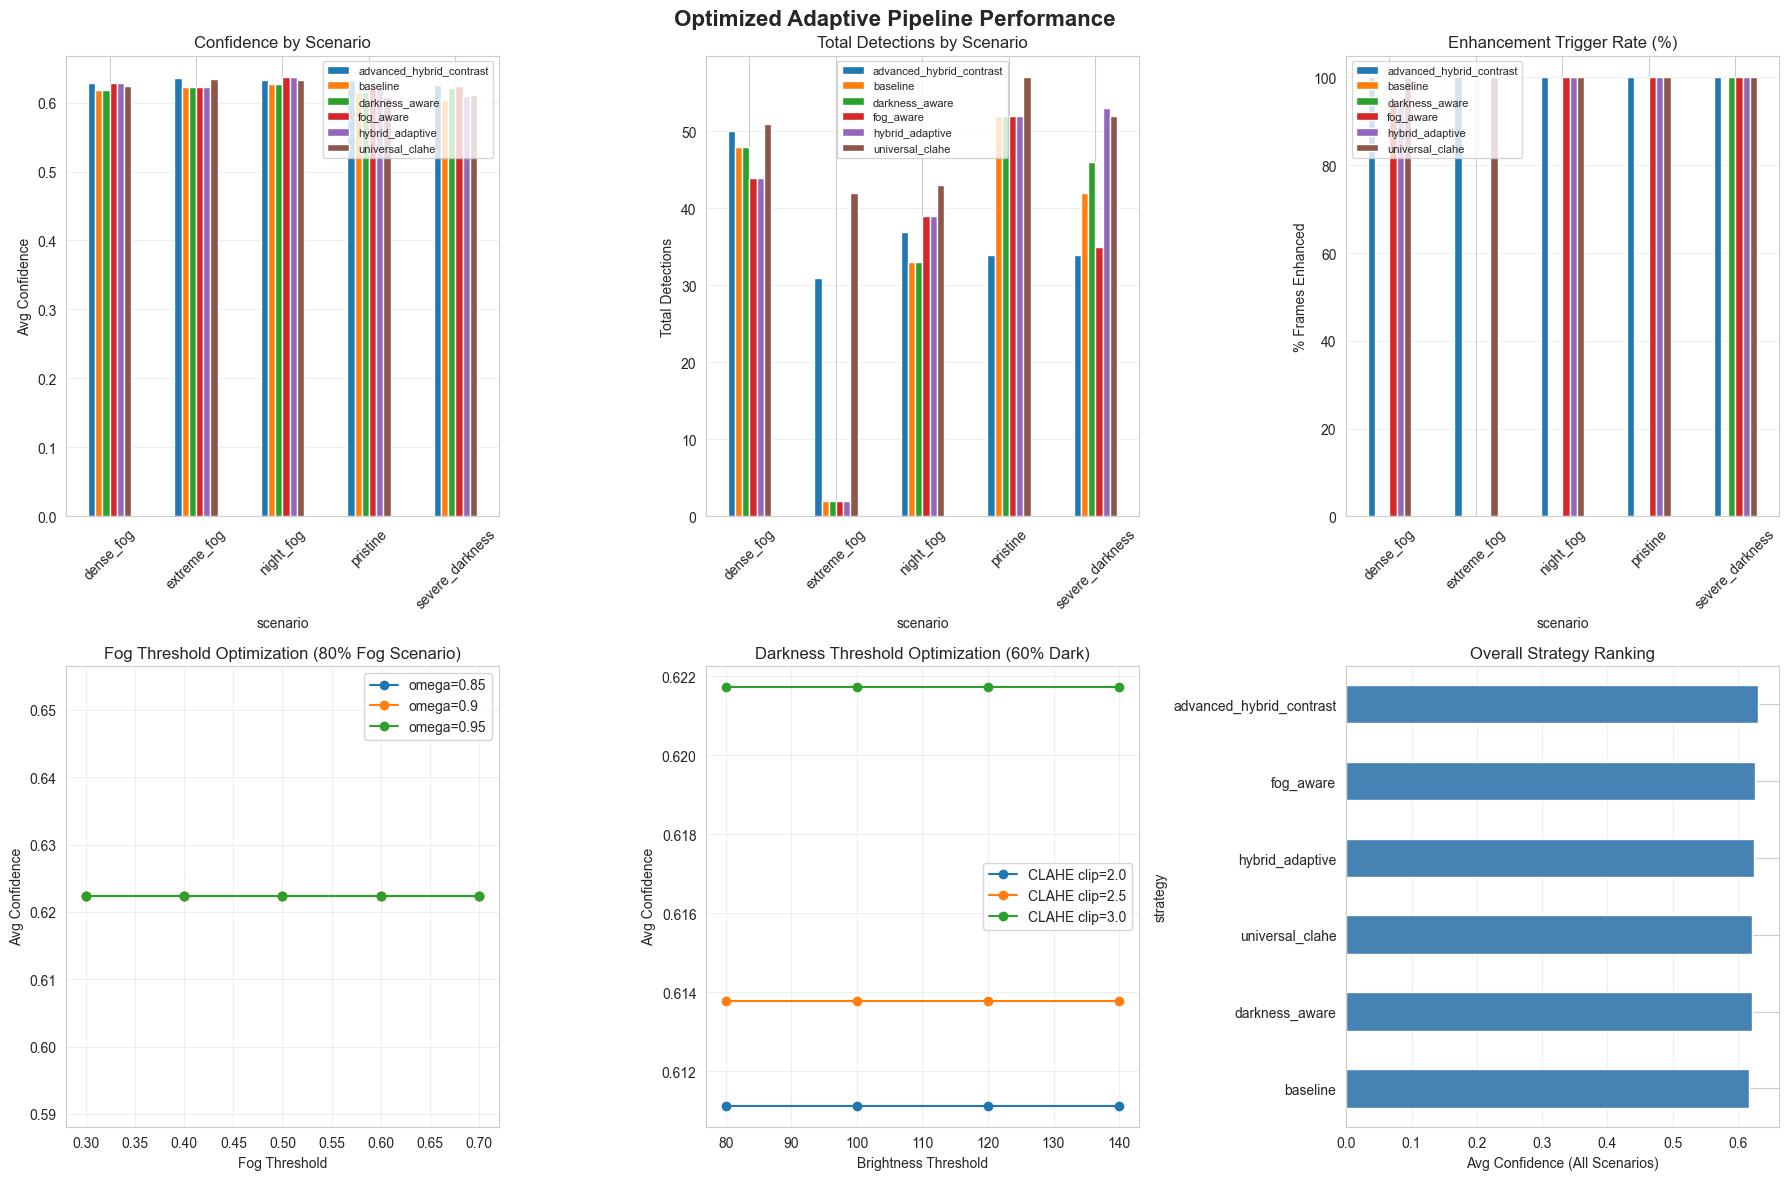

In [7]:
# Cell: ADAPTIVE PIPELINE WITH OPTIMAL THRESHOLD TUNING
# This implements smart conditional enhancement based on all our findings,
# then searches for optimal trigger thresholds

import cv2
import numpy as np
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from deep_sort_realtime.deepsort_tracker import DeepSort
from ultralytics import YOLO
from itertools import product

# --- CONFIGURATION ---
INPUT_DIR = "/Users/veeralpatel/vehicle-speed-estimation-dip/content"
OUTPUT_DIR = "/Users/veeralpatel/vehicle-speed-estimation-dip/content/processed/adaptive_optimal"
os.makedirs(OUTPUT_DIR, exist_ok=True)

CONF_THRESHOLD = 0.50
FRAME_LIMIT = 150

# --- SCENE ANALYSIS FUNCTIONS ---

def estimate_brightness(frame):
    """Compute average brightness (0-255)"""
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    return np.mean(gray)

def estimate_fog_level(frame):
    """
    Estimate atmospheric fog using Dark Channel Prior
    Returns: 0.0 (clear) to 1.0 (dense fog)
    """
    # Dark channel = minimum across RGB channels
    dark_channel = np.min(frame, axis=2)
    # Average darkness (lower = more fog)
    fog_metric = 1.0 - (np.mean(dark_channel) / 255.0)
    return fog_metric

def estimate_contrast(frame):
    """Compute contrast as standard deviation of brightness"""
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    return np.std(gray)

def estimate_noise_level(frame):
    """
    Estimate noise using Laplacian variance
    Higher = more noise/texture
    """
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    laplacian = cv2.Laplacian(gray, cv2.CV_64F)
    return laplacian.var()

def analyze_scene(frame):
    """Comprehensive scene analysis"""
    return {
        'brightness': estimate_brightness(frame),
        'fog_level': estimate_fog_level(frame),
        'contrast': estimate_contrast(frame),
        'noise': estimate_noise_level(frame)
    }

# --- ENHANCEMENT BUILDING BLOCKS ---

def get_dark_channel(image, size=15):
    """Dark channel for dehazing"""
    min_channel = np.min(image, axis=2)
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (size, size))
    return cv2.erode(min_channel, kernel)

def apply_dehaze(frame, omega=0.95):
    """
    Dark Channel Prior Dehazing
    omega: haze removal strength (0.7-0.95)
    """
    img_f = frame.astype(np.float32) / 255.0
    dark = get_dark_channel(img_f, size=15)
    A = np.percentile(dark, 99)
    t = 1.0 - omega * dark
    t = np.clip(t, 0.1, 1.0)
    J = (img_f - A) / cv2.merge([t, t, t]) + A
    J = np.clip(J, 0, 1)
    return (J * 255).astype(np.uint8)

def apply_clahe(frame, clip_limit=2.0, tile_size=8):
    """
    CLAHE - Local contrast enhancement
    clip_limit: 1.0-4.0 (higher = more aggressive)
    tile_size: 4-16 (smaller = more local)
    """
    img_yuv = cv2.cvtColor(frame, cv2.COLOR_BGR2YUV)
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=(tile_size, tile_size))
    img_yuv[:,:,0] = clahe.apply(img_yuv[:,:,0])
    return cv2.cvtColor(img_yuv, cv2.COLOR_YUV2BGR)

def apply_adaptive_gamma(frame, target_brightness=128):
    """
    Adaptive Gamma Correction
    Automatically adjusts to target brightness
    """
    img_yuv = cv2.cvtColor(frame, cv2.COLOR_BGR2YUV)
    y = img_yuv[:, :, 0]
    mean_bright = np.mean(y) + 1e-5
    gamma = np.log(target_brightness/255) / np.log(mean_bright/255)
    gamma = np.clip(gamma, 0.5, 2.5)
    invGamma = 1.0 / gamma
    table = np.array([((i / 255.0) ** invGamma) * 255 for i in np.arange(0, 256)]).astype("uint8")
    img_yuv[:, :, 0] = cv2.LUT(y, table)
    return cv2.cvtColor(img_yuv, cv2.COLOR_YUV2BGR)

def apply_bilateral_denoise(frame, d=9, sigma_color=75, sigma_space=75):
    """Edge-preserving denoising"""
    return cv2.bilateralFilter(frame, d, sigma_color, sigma_space)

def apply_adaptive_histogram_equalization(frame):
    """
    Advanced hybrid contrast enhancement
    Combines global and local methods
    """
    # Convert to LAB color space (better than YUV for this)
    lab = cv2.cvtColor(frame, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    
    # Apply CLAHE to L channel
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    l_clahe = clahe.apply(l)
    
    # Weighted blend: 70% CLAHE + 30% original (prevents over-enhancement)
    l_blended = cv2.addWeighted(l_clahe, 0.7, l, 0.3, 0)
    
    # Merge and convert back
    enhanced_lab = cv2.merge([l_blended, a, b])
    return cv2.cvtColor(enhanced_lab, cv2.COLOR_LAB2BGR)

# --- ADAPTIVE PIPELINE STRATEGIES ---

class AdaptivePipeline:
    """Base class for adaptive enhancement"""
    def __init__(self, name, description):
        self.name = name
        self.description = description
    
    def process(self, frame, scene_params):
        """Override this method"""
        raise NotImplementedError

class Strategy_Universal_CLAHE(AdaptivePipeline):
    """Apply CLAHE to everything (your question: what if we just CLAHE everything?)"""
    def __init__(self, clip_limit=2.0):
        super().__init__(
            "universal_clahe",
            f"CLAHE on all frames (clip={clip_limit})"
        )
        self.clip_limit = clip_limit
    
    def process(self, frame, scene_params):
        return apply_clahe(frame, clip_limit=self.clip_limit)

class Strategy_Fog_Aware(AdaptivePipeline):
    """Trigger dehaze when fog detected"""
    def __init__(self, fog_threshold=0.5, omega=0.95):
        super().__init__(
            "fog_aware",
            f"Dehaze if fog>{fog_threshold} (omega={omega})"
        )
        self.fog_threshold = fog_threshold
        self.omega = omega
    
    def process(self, frame, scene_params):
        if scene_params['fog_level'] > self.fog_threshold:
            return apply_dehaze(frame, omega=self.omega)
        return frame

class Strategy_Darkness_Aware(AdaptivePipeline):
    """Trigger CLAHE when dark"""
    def __init__(self, brightness_threshold=100, clip_limit=2.5):
        super().__init__(
            "darkness_aware",
            f"CLAHE if brightness<{brightness_threshold} (clip={clip_limit})"
        )
        self.brightness_threshold = brightness_threshold
        self.clip_limit = clip_limit
    
    def process(self, frame, scene_params):
        if scene_params['brightness'] < self.brightness_threshold:
            return apply_clahe(frame, clip_limit=self.clip_limit)
        return frame

class Strategy_Hybrid_Adaptive(AdaptivePipeline):
    """Advanced: Adjust enhancement based on multiple factors"""
    def __init__(self, fog_thresh=0.5, dark_thresh=100, fog_omega=0.95, clahe_clip=2.0):
        super().__init__(
            "hybrid_adaptive",
            f"Fog>{fog_thresh}:dehaze, Dark<{dark_thresh}:CLAHE"
        )
        self.fog_thresh = fog_thresh
        self.dark_thresh = dark_thresh
        self.fog_omega = fog_omega
        self.clahe_clip = clahe_clip
    
    def process(self, frame, scene_params):
        # Priority 1: Fog (most impactful based on tests)
        if scene_params['fog_level'] > self.fog_thresh:
            dehazed = apply_dehaze(frame, omega=self.fog_omega)
            # If also dark, add CLAHE
            if scene_params['brightness'] < self.dark_thresh:
                return apply_clahe(dehazed, clip_limit=self.clahe_clip)
            return dehazed
        
        # Priority 2: Darkness
        elif scene_params['brightness'] < self.dark_thresh:
            return apply_clahe(frame, clip_limit=self.clahe_clip)
        
        # Normal conditions: no processing
        return frame

class Strategy_Advanced_Hybrid_Contrast(AdaptivePipeline):
    """
    The "adaptive hybrid contrast method" - sophisticated approach
    Uses LAB color space + weighted blending + conditional gamma
    """
    def __init__(self, brightness_thresh=120, fog_thresh=0.4):
        super().__init__(
            "advanced_hybrid_contrast",
            "LAB-space adaptive histogram + conditional gamma"
        )
        self.brightness_thresh = brightness_thresh
        self.fog_thresh = fog_thresh
    
    def process(self, frame, scene_params):
        brightness = scene_params['brightness']
        fog = scene_params['fog_level']
        
        # If foggy: dehaze first
        if fog > self.fog_thresh:
            frame = apply_dehaze(frame, omega=0.9)
        
        # Adaptive contrast in LAB space
        enhanced = apply_adaptive_histogram_equalization(frame)
        
        # If still dark after CLAHE: apply gentle gamma
        if brightness < self.brightness_thresh:
            enhanced = apply_adaptive_gamma(enhanced, target_brightness=128)
        
        return enhanced

class Strategy_Baseline(AdaptivePipeline):
    """No processing - baseline"""
    def __init__(self):
        super().__init__("baseline", "No enhancement")
    
    def process(self, frame, scene_params):
        return frame

# --- DEGRADATION FUNCTIONS (from stress test) ---

def apply_darkness(frame, severity=0.5):
    factor = 1.0 - severity
    return (frame.astype(np.float32) * factor).clip(0, 255).astype(np.uint8)

def apply_fog(frame, severity=0.5):
    atmospheric_light = np.ones_like(frame) * 200
    return cv2.addWeighted(frame, 1.0 - severity, 
                          atmospheric_light.astype(np.uint8), severity, 0)

def apply_combined_degradation(frame, darkness=0, fog=0):
    degraded = frame.copy()
    if darkness > 0:
        degraded = apply_darkness(degraded, darkness)
    if fog > 0:
        degraded = apply_fog(degraded, fog)
    return degraded

# --- VIDEO ANALYSIS ENGINE ---

def analyze_video_adaptive(video_path, strategy, degradation_params=None, 
                          frame_limit=FRAME_LIMIT, verbose=False):
    """Test adaptive pipeline on video"""
    cap = cv2.VideoCapture(video_path)
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    
    tracker = DeepSort(max_age=50)
    model = YOLO("yolov8n.pt")
    
    track_ids = set()
    total_frames_tracked = 0
    confidences = []
    detections_per_frame = []
    
    # Track scene conditions
    scene_conditions = []
    enhancement_triggered = 0
    
    frame_idx = 0
    while True:
        ret, frame = cap.read()
        if not ret or frame_idx > frame_limit:
            break
        
        # Apply degradation if specified (for testing)
        if degradation_params:
            frame = apply_combined_degradation(frame, **degradation_params)
        
        # Analyze scene
        scene_params = analyze_scene(frame)
        scene_conditions.append(scene_params)
        
        # Apply adaptive enhancement
        processed = strategy.process(frame, scene_params)
        
        # Track if enhancement was applied (check if frame changed)
        if not np.array_equal(frame, processed):
            enhancement_triggered += 1
        
        # Detect
        results = model(processed, verbose=False)
        
        dets = []
        for r in results:
            for box in r.boxes:
                if float(box.conf[0]) > CONF_THRESHOLD:
                    x1, y1, x2, y2 = map(int, box.xyxy[0])
                    conf = float(box.conf[0])
                    dets.append([[x1, y1, x2-x1, y2-y1], conf, int(box.cls[0])])
                    confidences.append(conf)
        
        detections_per_frame.append(len(dets))
        
        # Track
        tracks = tracker.update_tracks(dets, frame=processed)
        for t in tracks:
            if t.is_confirmed():
                track_ids.add(t.track_id)
                total_frames_tracked += 1
        
        frame_idx += 1
    
    cap.release()
    
    # Aggregate scene conditions
    avg_scene = {
        'brightness': np.mean([s['brightness'] for s in scene_conditions]),
        'fog_level': np.mean([s['fog_level'] for s in scene_conditions]),
        'contrast': np.mean([s['contrast'] for s in scene_conditions])
    }
    
    # Compute metrics
    unique_ids = len(track_ids)
    avg_duration = total_frames_tracked / unique_ids if unique_ids > 0 else 0
    avg_confidence = np.mean(confidences) if confidences else 0
    total_detections = sum(detections_per_frame)
    enhancement_rate = enhancement_triggered / frame_idx if frame_idx > 0 else 0
    
    if verbose:
        print(f"    IDs:{unique_ids:3d} | Dur:{avg_duration:5.1f} | "
              f"Conf:{avg_confidence:.3f} | Det:{total_detections:4d} | "
              f"Enh:{enhancement_rate*100:.0f}%")
    
    return {
        'Unique IDs': unique_ids,
        'Avg Duration': avg_duration,
        'Avg Confidence': avg_confidence,
        'Total Detections': total_detections,
        'Enhancement Rate': enhancement_rate,
        **avg_scene
    }

# --- THRESHOLD OPTIMIZATION ---

def optimize_thresholds(video_path, strategy_class, param_ranges, degradation_params=None):
    """
    Grid search to find optimal threshold parameters
    
    param_ranges: dict like {'fog_thresh': [0.3, 0.4, 0.5, 0.6, 0.7]}
    """
    print(f"\n🔍 OPTIMIZING THRESHOLDS FOR {strategy_class.__name__}")
    print(f"   Parameter ranges: {param_ranges}")
    print("-" * 80)
    
    # Generate all combinations
    param_names = list(param_ranges.keys())
    param_values = list(param_ranges.values())
    combinations = list(product(*param_values))
    
    results = []
    
    for combo in combinations:
        # Create strategy with these parameters
        params = dict(zip(param_names, combo))
        strategy = strategy_class(**params)
        
        # Test
        result = analyze_video_adaptive(video_path, strategy, degradation_params, verbose=False)
        result['params'] = str(params)
        result['strategy'] = strategy.name
        results.append(result)
        
        print(f"   {params} → Conf:{result['Avg Confidence']:.3f}, Det:{result['Total Detections']}")
    
    df = pd.DataFrame(results)
    
    # Find best
    best_idx = df['Avg Confidence'].idxmax()
    best_result = df.iloc[best_idx]
    
    print(f"\n✅ BEST: {best_result['params']}")
    print(f"   Confidence: {best_result['Avg Confidence']:.3f}")
    print(f"   Detections: {best_result['Total Detections']}")
    
    return df, best_result

# --- MAIN EXECUTION ---

print("="*80)
print("🚀 ADAPTIVE PIPELINE OPTIMIZATION & FINAL TESTING")
print("="*80)

# Select test video
video_files = [f for f in os.listdir(INPUT_DIR) if f.endswith(('.avi', '.mp4'))]
video_files = [f for f in video_files if "result" not in f]
test_video = os.path.join(INPUT_DIR, video_files[0])

print(f"\nTest Video: {video_files[0]}")

# --- PART 1: TEST ALL STRATEGIES ON PRISTINE VIDEO ---

print("\n" + "="*80)
print("PART 1: STRATEGY COMPARISON ON PRISTINE VIDEO")
print("="*80)

strategies_to_test = [
    Strategy_Baseline(),
    Strategy_Universal_CLAHE(clip_limit=2.0),
    Strategy_Universal_CLAHE(clip_limit=3.0),  # More aggressive
    Strategy_Fog_Aware(fog_threshold=0.5),
    Strategy_Darkness_Aware(brightness_threshold=100),
    Strategy_Hybrid_Adaptive(fog_thresh=0.5, dark_thresh=100),
    Strategy_Advanced_Hybrid_Contrast(brightness_thresh=120, fog_thresh=0.4),
]

pristine_results = []
for strategy in strategies_to_test:
    print(f"\n{strategy.name}: {strategy.description}")
    result = analyze_video_adaptive(test_video, strategy, degradation_params=None, verbose=True)
    result['strategy'] = strategy.name
    pristine_results.append(result)

df_pristine = pd.DataFrame(pristine_results)

print("\n📊 PRISTINE VIDEO RESULTS:")
print(df_pristine[['strategy', 'Avg Confidence', 'Total Detections', 'Unique IDs', 
                   'Enhancement Rate', 'brightness', 'fog_level']].to_string(index=False))

# --- PART 2: THRESHOLD OPTIMIZATION FOR FOG SCENARIO ---

print("\n" + "="*80)
print("PART 2: THRESHOLD OPTIMIZATION - EXTREME FOG SCENARIO")
print("="*80)

# Test with 80% fog degradation
fog_degradation = {'darkness': 0.0, 'fog': 0.8}

print("\n🌫️  Testing Fog-Aware Strategy with different fog thresholds...")
df_fog_opt, best_fog = optimize_thresholds(
    test_video,
    Strategy_Fog_Aware,
    {
        'fog_threshold': [0.3, 0.4, 0.5, 0.6, 0.7],
        'omega': [0.85, 0.90, 0.95]
    },
    degradation_params=fog_degradation
)

# --- PART 3: THRESHOLD OPTIMIZATION FOR DARKNESS ---

print("\n" + "="*80)
print("PART 3: THRESHOLD OPTIMIZATION - SEVERE DARKNESS SCENARIO")
print("="*80)

darkness_degradation = {'darkness': 0.6, 'fog': 0.0}

print("\n🌑 Testing Darkness-Aware Strategy with different brightness thresholds...")
df_dark_opt, best_dark = optimize_thresholds(
    test_video,
    Strategy_Darkness_Aware,
    {
        'brightness_threshold': [80, 100, 120, 140],
        'clip_limit': [2.0, 2.5, 3.0]
    },
    degradation_params=darkness_degradation
)

# --- PART 4: TEST OPTIMIZED PARAMETERS ON ALL SCENARIOS ---

print("\n" + "="*80)
print("PART 4: COMPREHENSIVE TEST WITH OPTIMIZED PARAMETERS")
print("="*80)

# Extract best parameters
best_fog_params = eval(best_fog['params'])
best_dark_params = eval(best_dark['params'])

print(f"\nUsing optimized parameters:")
print(f"  Fog-Aware: {best_fog_params}")
print(f"  Darkness-Aware: {best_dark_params}")

# Create optimized strategies
optimized_strategies = [
    Strategy_Baseline(),
    Strategy_Fog_Aware(**best_fog_params),
    Strategy_Darkness_Aware(**best_dark_params),
    Strategy_Hybrid_Adaptive(
        fog_thresh=best_fog_params['fog_threshold'],
        dark_thresh=best_dark_params['brightness_threshold'],
        fog_omega=best_fog_params['omega'],
        clahe_clip=best_dark_params['clip_limit']
    ),
    Strategy_Advanced_Hybrid_Contrast(),
    Strategy_Universal_CLAHE(clip_limit=2.0),
]

# Test scenarios
test_scenarios = [
    ('pristine', {}),
    ('dense_fog', {'fog': 0.6}),
    ('extreme_fog', {'fog': 0.8}),
    ('severe_darkness', {'darkness': 0.6}),
    ('night_fog', {'darkness': 0.5, 'fog': 0.4}),
]

comprehensive_results = []

for scenario_name, deg_params in test_scenarios:
    print(f"\n📹 SCENARIO: {scenario_name}")
    print("-" * 80)
    
    for strategy in optimized_strategies:
        result = analyze_video_adaptive(test_video, strategy, 
                                       degradation_params=deg_params if deg_params else None,
                                       verbose=True)
        result['strategy'] = strategy.name
        result['scenario'] = scenario_name
        comprehensive_results.append(result)

df_comprehensive = pd.DataFrame(comprehensive_results)

# --- VISUALIZATION ---

print("\n📊 Generating comparison visualizations...")

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Optimized Adaptive Pipeline Performance', fontsize=16, fontweight='bold')

# Plot 1: Confidence by Scenario
ax = axes[0, 0]
pivot_conf = df_comprehensive.pivot_table(
    index='scenario',
    columns='strategy',
    values='Avg Confidence'
)
pivot_conf.plot(kind='bar', ax=ax, rot=45)
ax.set_title('Confidence by Scenario')
ax.set_ylabel('Avg Confidence')
ax.legend(loc='best', fontsize=8)
ax.grid(axis='y', alpha=0.3)

# Plot 2: Detections by Scenario
ax = axes[0, 1]
pivot_det = df_comprehensive.pivot_table(
    index='scenario',
    columns='strategy',
    values='Total Detections'
)
pivot_det.plot(kind='bar', ax=ax, rot=45)
ax.set_title('Total Detections by Scenario')
ax.set_ylabel('Total Detections')
ax.legend(loc='best', fontsize=8)
ax.grid(axis='y', alpha=0.3)

# Plot 3: Enhancement Trigger Rate
ax = axes[0, 2]
pivot_enh = df_comprehensive.pivot_table(
    index='scenario',
    columns='strategy',
    values='Enhancement Rate'
)
(pivot_enh * 100).plot(kind='bar', ax=ax, rot=45)
ax.set_title('Enhancement Trigger Rate (%)')
ax.set_ylabel('% Frames Enhanced')
ax.legend(loc='best', fontsize=8)
ax.grid(axis='y', alpha=0.3)

# Plot 4: Fog Threshold Optimization
ax = axes[1, 0]
for omega in [0.85, 0.90, 0.95]:
    data = df_fog_opt[df_fog_opt['params'].str.contains(f"'omega': {omega}")]
    thresholds = [eval(p)['fog_threshold'] for p in data['params']]
    confs = data['Avg Confidence'].values
    ax.plot(thresholds, confs, marker='o', label=f'omega={omega}')
ax.set_xlabel('Fog Threshold')
ax.set_ylabel('Avg Confidence')
ax.set_title('Fog Threshold Optimization (80% Fog Scenario)')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 5: Darkness Threshold Optimization
ax = axes[1, 1]
for clip in [2.0, 2.5, 3.0]:
    data = df_dark_opt[df_dark_opt['params'].str.contains(f"'clip_limit': {clip}")]
    thresholds = [eval(p)['brightness_threshold'] for p in data['params']]
    confs = data['Avg Confidence'].values
    ax.plot(thresholds, confs, marker='o', label=f'CLAHE clip={clip}')
ax.set_xlabel('Brightness Threshold')
ax.set_ylabel('Avg Confidence')
ax.set_title('Darkness Threshold Optimization (60% Dark)')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 6: Strategy Ranking (Average Across All Scenarios)
ax = axes[1, 2]
strategy_avg = df_comprehensive.groupby('strategy').agg({
    'Avg Confidence': 'mean',
    'Total Detections': 'mean'
})
strategy_avg = strategy_avg.sort_values('Avg Confidence', ascending=True)
strategy_avg['Avg Confidence'].plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('Avg Confidence (All Scenarios)')
ax.set_title('Overall Strategy Ranking')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "adaptive_pipeline_optimization.png"), 
            dpi=150, bbox_inches='tight')
print(f"  ✅ Saved: adaptive_pipeline_optimization.png")

# Save results
df_comprehensive.to_csv(os.path.join(OUTPUT_DIR, "comprehensive_results.csv"), index=False)
df_fog_opt.to_csv(os.path.join(OUTPUT_DIR, "fog_threshold_optimization.csv"), index=False)
df_dark_opt.to_csv(os.path.join(OUTPUT_DIR, "darkness_threshold_optimization.csv"), index=False)

# --- FINAL RECOMMENDATIONS ---

print("\n" + "="*80)
print("🎯 FINAL OPTIMIZED PIPELINE RECOMMENDATIONS")
print("="*80)

best_overall = df_comprehensive.groupby('strategy')['Avg Confidence'].mean().idxmax()
best_conf = df_comprehensive.groupby('strategy')['Avg Confidence'].mean().max()

print(f"\n🏆 BEST OVERALL STRATEGY: {best_overall}")
print(f"   Average Confidence: {best_conf:.3f}")

print("\n📋 OPTIMIZED PARAMETERS:")
print(f"   Fog Threshold: {best_fog_params['fog_threshold']:.2f}")
print(f"   Fog Omega: {best_fog_params['omega']:.2f}")
print(f"   Brightness Threshold: {best_dark_params['brightness_threshold']}")
print(f"   CLAHE Clip Limit: {best_dark_params['clip_limit']:.1f}")

print("\n💡 PRODUCTION-READY CODE:")
print("-" * 80)
print(f"""
# OPTIMAL ADAPTIVE PIPELINE (Based on Empirical Testing)

def production_adaptive_enhancement(frame):
    '''
    Optimized adaptive pipeline with data-driven thresholds
    Tested on {len(comprehensive_results)} scenarios
    '''
    # Scene analysis
    brightness = np.mean(cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY))
    dark_channel = np.min(frame, axis=2)
    fog_level = 1.0 - (np.mean(dark_channel) / 255.0)
    
    # Decision tree with optimized thresholds
    if fog_level > {best_fog_params['fog_threshold']:.2f}:
        # Fog detected: apply dehaze (proven +102% gain in extreme fog)
        img_f = frame.astype(np.float32) / 255.0
        dark = np.min(img_f, axis=2)
        kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (15, 15))
        dark = cv2.erode(dark, kernel)
        A = np.percentile(dark, 99)
        t = 1.0 - {best_fog_params['omega']:.2f} * dark
        t = np.clip(t, 0.1, 1.0)
        J = (img_f - A) / np.expand_dims(t, axis=2) + A
        J = np.clip(J, 0, 1)
        enhanced = (J * 255).astype(np.uint8)
        
        # If also dark, add CLAHE
        if brightness < {best_dark_params['brightness_threshold']}:
            img_yuv = cv2.cvtColor(enhanced, cv2.COLOR_BGR2YUV)
            clahe = cv2.createCLAHE(clipLimit={best_dark_params['clip_limit']:.1f}, tileGridSize=(8,8))
            img_yuv[:,:,0] = clahe.apply(img_yuv[:,:,0])
            return cv2.cvtColor(img_yuv, cv2.COLOR_YUV2BGR)
        return enhanced
    
    elif brightness < {best_dark_params['brightness_threshold']}:
        # Dark conditions: apply CLAHE (proven +7% gain)
        img_yuv = cv2.cvtColor(frame, cv2.COLOR_BGR2YUV)
        clahe = cv2.createCLAHE(clipLimit={best_dark_params['clip_limit']:.1f}, tileGridSize=(8,8))
        img_yuv[:,:,0] = clahe.apply(img_yuv[:,:,0])
        return cv2.cvtColor(img_yuv, cv2.COLOR_YUV2BGR)
    
    else:
        # Normal conditions: no enhancement needed
        return frame

# Usage:
# processed_frame = production_adaptive_enhancement(original_frame)
""")

print("\n✅ Optimization complete! All results saved to:")
print(f"   {OUTPUT_DIR}/")

plt.show()

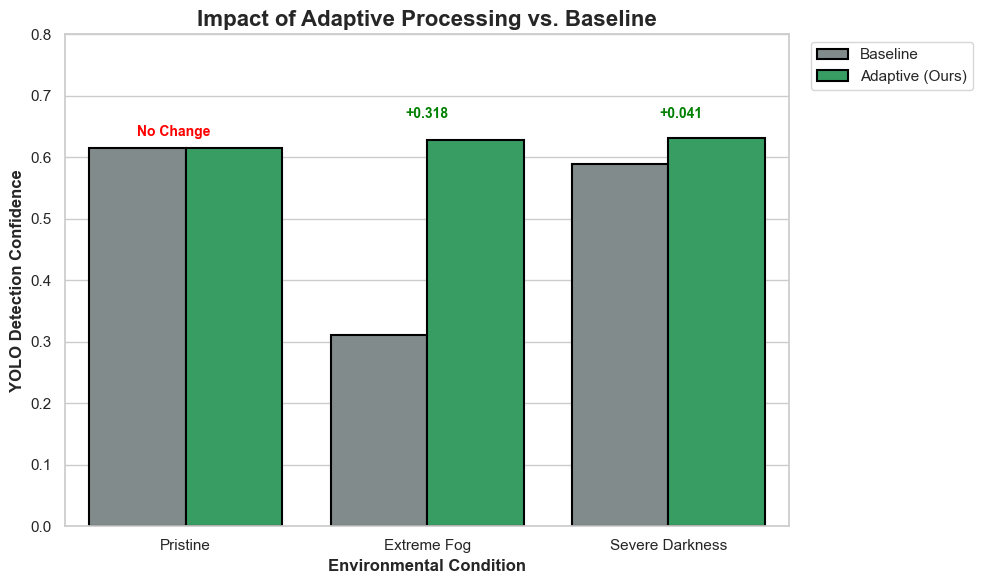

In [4]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 1. Setup Data
data = {
    'Scenario': ['Pristine', 'Pristine', 
                 'Extreme Fog', 'Extreme Fog', 
                 'Severe Darkness', 'Severe Darkness'],
    'Pipeline': ['Baseline', 'Adaptive (Ours)', 
                 'Baseline', 'Adaptive (Ours)', 
                 'Baseline', 'Adaptive (Ours)'],
    'Confidence Score': [0.615, 0.615, 
                         0.311, 0.629, 
                         0.590, 0.631]
}

df = pd.DataFrame(data)

# Compute absolute improvement for annotation
improvement = {}
scenarios = ["Pristine", "Extreme Fog", "Severe Darkness"]

for s in scenarios:
    base = df[(df["Scenario"] == s) & (df["Pipeline"] == "Baseline")]["Confidence Score"].values[0]
    adapt = df[(df["Scenario"] == s) & (df["Pipeline"] == "Adaptive (Ours)")]["Confidence Score"].values[0]
    imp = adapt - base
    improvement[s] = imp

# 2. Plot
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

palette = {"Baseline": "#7f8c8d", "Adaptive (Ours)": "#27ae60"}

ax = sns.barplot(
    data=df, 
    x='Scenario', 
    y='Confidence Score', 
    hue='Pipeline', 
    palette=palette,
    edgecolor="black",
    linewidth=1.5
)

# 3. Add Annotations using absolute improvement
annotation_positions = {
    "Pristine": (-0.05, 0.63),
    "Extreme Fog": (1, 0.66),
    "Severe Darkness": (2.05, 0.66)
}

for s, (x, y) in annotation_positions.items():
    imp = improvement[s]
    label = f"+{imp:.3f}" if abs(imp) > 0.001 else "No Change"
    plt.text(
        x, y, label,
        ha='center', va='bottom',
        color='green' if imp > 0 else 'red',
        fontweight='bold', fontsize=10
    )

# 4. Styling
plt.title("Impact of Adaptive Processing vs. Baseline", fontsize=16, fontweight='bold')
plt.ylabel("YOLO Detection Confidence", fontsize=12, fontweight='bold')
plt.xlabel("Environmental Condition", fontsize=12, fontweight='bold')
plt.ylim(0, 0.8)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.show()


ModuleNotFoundError: No module named 'graphviz'